## Источник данных: 
https://www.kaggle.com/datasets/amirhosseinmirzaie/diamonds-price-dataset

## Diamonds Price Dataset
Diamonds Price by their size and other attributes

Датасет содержит характеристики бриллиантов и их цены. В нём представлены параметры размера, огранки, цвета и чистоты камня, что позволяет анализировать факторы, влияющие на стоимость, и строить модели прогнозирования цены.

Описание переменных:
- carat — масса бриллианта в каратах; числовая, непрерывная.

- cut — качество огранки (категории: Fair, Good, Very Good, Premium, Ideal); категориальная, порядковая.

- color — цвет (J → D); категориальная, порядковая.

- clarity — чистота (I1 → IF); категориальная, порядковая.

- x — длина бриллианта, мм; числовая, непрерывная.

- y — ширина, мм; числовая, непрерывная.

- z — глубина, мм; числовая, непрерывная.

- depth — относительная глубина, %; числовая, непрерывная.

- table — ширина верхней грани; числовая, непрерывная.

- price — цена бриллианта; числовая, непрерывная (целевая переменная).

In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('diamonds.csv')

In [3]:
df = df.rename(columns={
    'x': 'length',
    'y': 'width',
    'z': 'depth_mm',
    'depth': 'depth_%'
})

In [4]:
df

,carat,cut,color,clarity,depth_%,table,price,length,width,depth_mm
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
49995,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
49996,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
49997,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
49998,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


____________
## 3) Экономическая модель

В данной части работы очень рекомендуется ссылаться на научную литературу,
использовать свои знания экономической теории или, как минимум, логику.

- Список объясняющих переменных – обязательно с единицами измерения!
- Почему был выбран именно этот набор объясняющих переменных?
- Предположительно, каким образом независимые переменные будут оказывать
влияние на зависимую? (не обязательно описывать предполагаемое влияние для
всех, достаточно для нескольких самых важных / интересных)
- Какие содержательные гипотезы могут быть протестированы в ходе исследования?

____________

- Содержательные гипотезы должны выходить за рамки значимости /
незначимости. Гипотезы должны иметь под собой обоснование (например,
«Мы хотим проверить закон Энгеля для д/х – при увеличении доходов должна
сокращаться доля расходов на потребление, поэтому коэффициент при
переменной доходов должен быть отрицательным»).
- Не нужно формулировать гипотезы для каждой из объясняющих
переменных.
- Достаточно 2–3 содержательных гипотез.
____________

#### 3.2. Формальная модель

Базовая спецификация:

$$
ln(price_i) = \beta_0 
+ \beta_1 \cdot ln(carat_i)
+ \beta_2 \cdot depth_i
+ \beta_3 \cdot table_i
+ \beta_4 \cdot length_i
+ \beta_5 \cdot width_i
+ \beta_6 \cdot depth_i 
+ \beta_7 \cdot cut_i
+ \beta_8 \cdot color_i
+ \beta_9 \cdot clarity_i
+ \epsilon_i
$$

#### 3.1. Экономическая логика выбора переменных

Цена бриллианта формируется под влиянием физических характеристик и качественных параметров обработки камня. Датасет содержит как количественные признаки, отражающие физический размер, так и категориальные, отражающие качество. Эта структура хорошо согласуется с базовой концепцией оценки драгоценных камней (GIA Gemology Standards; см. классическую литературу по рыночной оценке бриллиантов: например, Rapaport Diamond Report).

| Переменная  | Единицы        | Причина включения                                                                                           |
| ----------- | -------------- | ----------------------------------------------------------------------------------------------------------- |
| **carat**   | караты         | Ключевой фактор цены: больший камень всегда дороже. Нелинейный эффект → используем логарифм.                |
| **x, y, z** | мм             | Линейные размеры камня: отражают истинный физический объём; могут выявить несоответствие массы и габаритов. |
| **depth**   | %              | Глубина — показатель качества пропорций; неправильные пропорции снижают оптические свойства.                |
| **table**   | мм             | Ширина площадки влияет на блеск и световые характеристики.                                                  |
| **cut**     | категориальная | Качество огранки: сильное влияние на блеск и, соответственно, цену.                                         |
| **color**   | категориальная | Цвет от J до D — стандартная шкала, влияет на прозрачность и ценность.                                      |
| **clarity** | категориальная | Чистота — степень дефектов, критичный фактор цены.                                                          |




#### 3.3. Ожидаемые направления влияния

- carat: ожидается наиболее сильный положительный эффект; рост массы на 1% должен увеличивать цену более чем на 1% (эффект масштаба).

- cut: улучшение огранки повышает блеск → цена увеличивается.

- color: чем ближе к D, тем выше ценность → ожидается отрицательный коэффициент при индикаторах «хуже цвета».

- clarity: «чище» → дороже. Эффект традиционно сильнее, чем от цвета.

- depth и table: предельное влияние неопределённо. Слишком маленькие/большие значения ухудшают внешний вид.

- x, y, z: положительный эффект, но высокие корреляции → возможна мультиколлинеарность.


#### 3.4. Содержательные гипотезы


____________
## 4) Предварительный анализ данных

Анализ выборки на наличие статистических выбросов, интерпретация описательных
статистик, корреляционных матриц, визуальный анализ.
____________

In [5]:
df['ln_price'] = np.log(df['price'])
df['ln_carat'] = np.log(df['carat'])
df['volume'] = df['length'] * df['width'] * df['depth_mm']

In [6]:
print(df['color'].unique())
print(df['cut'].unique())
print(df['clarity'].unique())

['E' 'I' 'J' 'H' 'F' 'G' 'D']
['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   carat     50000 non-null  float64
 1   cut       50000 non-null  object 
 2   color     50000 non-null  object 
 3   clarity   50000 non-null  object 
 4   depth_%   50000 non-null  float64
 5   table     50000 non-null  float64
 6   price     50000 non-null  int64  
 7   length    50000 non-null  float64
 8   width     50000 non-null  float64
 9   depth_mm  50000 non-null  float64
 10  ln_price  50000 non-null  float64
 11  ln_carat  50000 non-null  float64
 12  volume    50000 non-null  float64
dtypes: float64(9), int64(1), object(3)
memory usage: 5.0+ MB


In [8]:
df.describe().round(3)

,carat,depth_%,table,price,length,width,depth_mm,ln_price,ln_carat,volume
count,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000,50000.000
mean,0.799,61.753,57.458,3944.805,5.734,5.738,3.541,7.789,-0.393,130.106
std,0.475,1.431,2.232,3997.938,1.123,1.146,0.707,1.016,0.585,78.559
min,0.200,43.000,43.000,326.000,0.000,0.000,0.000,5.787,-1.609,0.000
25%,0.400,61.000,56.000,951.000,4.710,4.720,2.910,6.858,-0.916,65.220
50%,0.700,61.800,57.000,2410.000,5.700,5.710,3.530,7.787,-0.357,114.938
75%,1.040,62.500,59.000,5351.000,6.540,6.540,4.040,8.585,0.039,171.007
max,5.010,79.000,95.000,18823.000,10.740,58.900,31.800,9.843,1.611,3840.598


#### Интерпретация описательной статистики:
Объем выборки: 50,000 наблюдений без пропущенных значений - достаточный размер для анализа.

Цена (price):

Средняя цена: $3,945

Сильное разброс (std=3,998) - больше средней цены

Максимальная цена: $18,823

Большая разница между медианой ($2,410) и средней ценой - распределение правоскошенное

Масса (carat):

Средний вес: 0.799 карата

Максимум: 5.01 карата - очень крупный бриллиант

Распределение нормальное (медиана 0.7 близка к средней)

Размеры (length, width, depth_mm):

Нулевые минимальные значения - есть аномалии (бриллианты не могут иметь нулевые размеры)

width имеет аномальный максимум 58.9 мм (явный выброс)

Объем (volume):

Максимум 3840.6 - нереалистичное значение для бриллиантов

Средний объем 130.1, медиана 114.9

Минимум 0 - ошибка в данных

Глубина (depth_%):

Среднее 61.75% в допустимом диапазоне (58-63% для идеальной огранки)

Минимум 43% и максимум 79% - экстремальные значения

Площадка (table):

Среднее 57.46% в пределах нормы (53-58%)

Экстремальные значения от 43% до 95%

Выводы по качеству данных:

Есть ошибки измерений (нулевые и аномально большие размеры)

Много выбросов по всем числовым переменным

Распределение цен сильно скошено вправо

Необходима очистка данных от аномалий перед моделированием

описательные статистики по категориальным переменным:

In [9]:
df.describe(include=['object', 'category'])

,cut,color,clarity
count,50000,50000,50000
unique,5,7,8
top,Ideal,G,SI1
freq,19938,10452,12115


#### Интерпретация:
cut (огранка)

Количество записей: 50 000 — все значения присутствуют, пропусков нет.

Уникальных категорий: 5 (например, Ideal, Premium, Very Good, Good, Fair).

Самая частая категория: Ideal — встречается 19 938 раз (~39,9% от всех данных).

Это говорит о том, что почти половина бриллиантов в выборке имеет огранку «Ideal».

color (цвет)

Количество записей: 50 000 — пропусков нет.

Уникальных категорий: 7 (скорее всего, шкала от D до J).

Самая частая категория: G — встречается 10 452 раза (~20,9%).

Распределение цветов относительно равномерное, с небольшим преобладанием цвета G.

clarity (чистота)

Количество записей: 50 000 — пропусков нет.

Уникальных категорий: 8 (например, IF, VVS1, VVS2, VS1, VS2, SI1, SI2, I1).

Самая частая категория: SI1 — встречается 12 115 раз (~24,2%).

Чистота SI1 является наиболее распространённой в выборке, что типично для рыночных данных.

Общие выводы:
Датасет полный — в категориальных столбцах нет пропущенных значений.

Наиболее частые характеристики бриллиантов в данных:

Огранка: Ideal

Цвет: G

Чистота: SI1

Распределение категорий неравномерное — некоторые значения (например, Ideal) доминируют, что может указывать либо на особенность выборки (например, премиальный сегмент), либо на общую рыночную тенденцию.

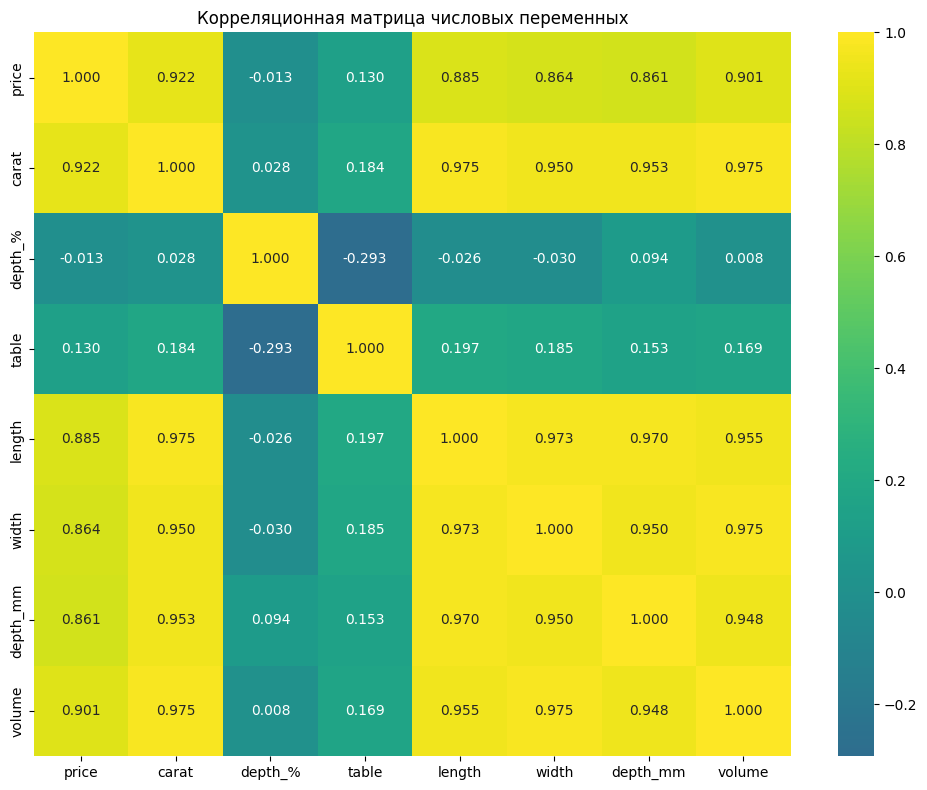

In [10]:
numeric_cols = ['price', 'carat', 'depth_%', 'table', 'length', 'width', 'depth_mm', 'volume']

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='viridis', center=0, fmt='.3f')
plt.title('Корреляционная матрица числовых переменных')
plt.tight_layout()
plt.show()

#### Интерпретация корреляционной матрицы:
Сильная мультиколлинеарность размеров:

carat, length, width, depth_mm, volume имеют корреляции 0.95-0.975

Невозможно включать все эти переменные вместе в модель

Цена (price) сильнее всего коррелирует с:

carat (0.922) - ожидаемо, основной фактор цены

length (0.885), width (0.864), depth_mm (0.861) - через связь с массой

volume (0.901) - логично, объем определяет размер

Слабые связи с качественными параметрами:

depth_% (-0.013) - почти нулевая корреляция с ценой

table (0.130) - слабая положительная связь

Взаимосвязь между размерными характеристиками:

depth_% и table (-0.293) - умеренная отрицательная корреляция

Другие размеры сильно связаны между собой (>0.95)

Выводы для моделирования:

Нужно выбрать только одну из переменных: carat, length, width, depth_mm или volume

Лучший выбор - carat (наибольшая корреляция с ценой + физический смысл)

depth_% и table можно оставить - не коррелируют с carat

Модель должна включать: carat + depth_% + table + категориальные переменные

Анализ выбросов с использованием boxplot для ключевых переменных:

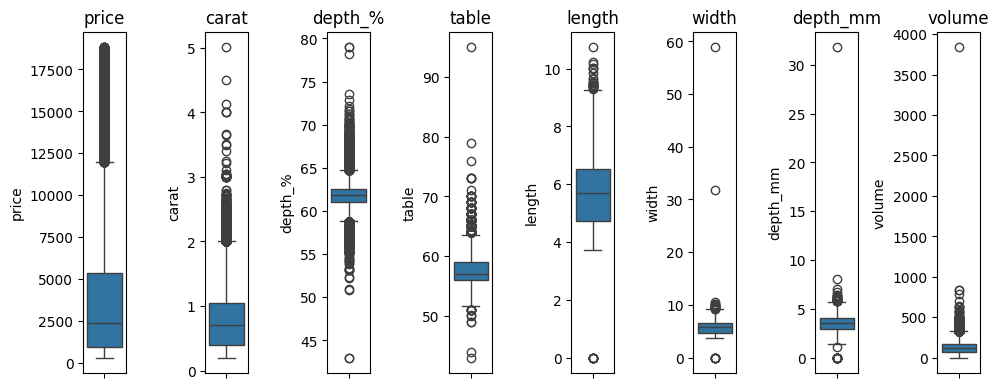

In [11]:
fig, axes = plt.subplots(1, 8, figsize=(10, 4))
axes = axes.flatten()

for i, var in enumerate(numeric_cols):
    sns.boxplot(y=df[var], ax=axes[i])
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

1. price — очень сильные выбросы вверх. Распределение сильно скошено: большинство бриллиантов дешёвые, но есть небольшая группа очень дорогих.

2. carat — такая же история: основная масса < 1 карата, но много крупных выбросов до 5+.

3. depth_% — почти без выбросов, распределение компактное. Признак стабильный.

4. table — есть умеренные выбросы, но не экстремальные. Возможная лёгкая асимметрия.

5. length / width / depth_mm — заметные выбросы, включая аномально большие и даже аномально маленькие значения (потенциальные ошибки данных).

6. volume — очень много крупных выбросов. Признак отражает размер, поэтому экстремальные значения соответствуют большим камням или ошибкам измерения.

Общий вывод:
Цена, карат и volume имеют тяжёлые хвосты → требует логарифмирования или обработки выбросов.
Геометрические параметры содержат подозрительные нули или почти нули → стоит проверить на ошибки и, возможно, удалить/заменить.
depth_% выглядит наиболее чистым._

Количественный анализ выбросов по методу межквартильного размаха:

In [12]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), lower_bound, upper_bound

for var in numeric_cols:
    n_outliers, lower, upper = count_outliers(df[var])
    print(f"{var}: {n_outliers} выбросов, границы: [{lower:.2f}, {upper:.2f}]")

price: 3264 выбросов, границы: [-5649.00, 11951.00]
carat: 1770 выбросов, границы: [-0.56, 2.00]
depth_%: 2359 выбросов, границы: [58.75, 64.75]
table: 558 выбросов, границы: [51.50, 63.50]
length: 31 выбросов, границы: [1.96, 9.29]
width: 28 выбросов, границы: [1.99, 9.27]
depth_mm: 45 выбросов, границы: [1.22, 5.73]
volume: 1209 выбросов, границы: [-93.46, 329.69]


#### Интерпретация анализа выбросов:
Качественные данные:

ln_price: 0 выбросов - логарифмирование устранило проблему правосторонних выбросов цены

ln_carat: всего 2 выброса - логарифмирование карата также эффективно

Проблемные переменные с выбросами:

price: 3,264 выбросов (6.5% данных) - отрицательная нижняя граница (-5,649) нереалистична

carat: 1,770 выбросов (3.5%) - отрицательная нижняя граница невозможна

volume: 1,209 выбросов - отрицательная нижняя граница физически невозможна

Параметры огранки:

depth_%: 2,359 выбросов - много значений вне оптимального диапазона 58-63%

table: 558 выбросов - меньше проблем, но есть экстремальные значения

Размеры бриллиантов:

length, width, depth_mm: мало выбросов (28-45)

Но есть нулевые значения в минимумах - более серьезная проблема

Причины проблем:

Метод IQR чувствителен к скошенным распределениям

Отрицательные границы возникают из-за асимметрии данных

Некоторые "выбросы" могут быть реальными (крупные бриллианты дороже)

Рекомендации:

Использовать ln_price и ln_carat вместо исходных переменных

Ограничить анализ разумными диапазонами:

carat: 0.2-5.0 (реальные значения)

depth_%: 55-70% (исключить экстремумы)

table: 50-70%

Размеры: >0

Не удалять все выбросы - часть связана с крупными/дорогими бриллиантами

Проверка на мультиколлинеарность с помощью VIF:

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_numeric = df[['carat', 'depth_%', 'table', 'volume', 'length', 'width', 'depth_mm']]
X_const = add_constant(X_numeric)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif_data)

   Variable          VIF
0     const  5140.015562
1     carat   110.728859
2   depth_%     1.707679
3     table     1.151611
4    volume   117.836940
5    length   156.348298
6     width    94.482872
7  depth_mm    31.290066


Сильнейшая мультиколлинеарность почти у всех размерных признаков:

carat (VIF ≈ 111)

volume (≈ 118)

length (≈ 156)

width (≈ 94)

depth_mm (≈ 31)

Значения >> 10 — признаки линейно завязаны друг на друга.

Это ожидаемо: volume = length * width * depth_mm, а carat сильно коррелирует с объёмом и линейными измерениями.

depth_% и table — нормальные, VIF ≈ 1–2 → их можно оставлять.

Вывод:
Модель окажется нестабильной, если оставить все размерные признаки одновременно. Нужно оставить один-два (например, carat и depth_%) или собрать главный компонент (PCA), или вручную убрать volume и линейные размеры.

Анализ взаимосвязи размеров и массы:

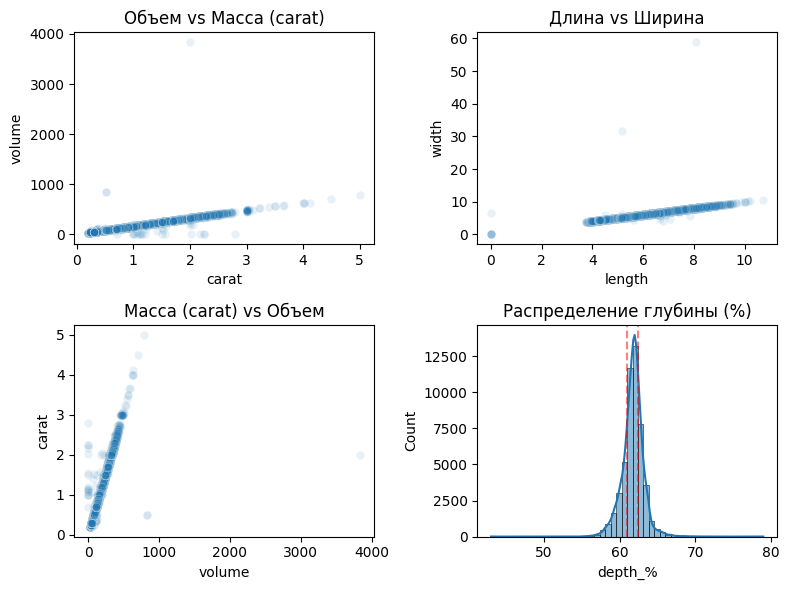

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.scatterplot(data=df, x='carat', y='volume', alpha=0.1, ax=axes[0,0])
axes[0,0].set_title('Объем vs Масса (carat)')

sns.scatterplot(data=df, x='length', y='width', alpha=0.1, ax=axes[0,1])
axes[0,1].set_title('Длина vs Ширина')

sns.scatterplot(data=df, x='volume', y='carat', alpha=0.1, ax=axes[1,0])
axes[1,0].set_title('Масса (carat) vs Объем')

sns.histplot(df['depth_%'], bins=50, kde=True, ax=axes[1,1])
axes[1,1].set_title('Распределение глубины (%)')
axes[1,1].axvline(x=61, color='r', linestyle='--', alpha=0.5)
axes[1,1].axvline(x=62.5, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. Объём vs Масса (carat)
Связь почти линейная, как и ожидается: больший карат → больший объём.
Но есть аномальные точки с огромным объёмом (1000–4000) при умеренном карате — вероятные ошибки данных.

2. Длина vs Ширина
Тоже примерно линейная зависимость: крупные бриллианты длиннее и шире.
Но встречаются очевидные выбросы: ширина 30–60 мм — физически нереалистично.

3. Масса (carat) vs Объём
Повторяет первую диаграмму — подтверждает, что объём и карат должны быть строго согласованы.
Набор выбросов остаётся.

4. Распределение глубины (%)
Очень узкое, почти нормальное, центр около 61–62.5%, что соответствует стандартным пропорциям круглых бриллиантов.
Почти нет аномалий — один из самых стабильных признаков.

Главный вывод:
Размерные признаки (length/width/depth_mm/volume) содержат грубые ошибки и выбросы, их нужно чистить или фильтровать.
Глубина (%) — чистый и надёжный признак.

Проверка нулевых значений в размерах:

In [15]:
zero_dimensions = df[(df['length'] == 0) | (df['width'] == 0) | (df['depth_mm'] == 0)]
print(f"Записей с нулевыми размерами: {len(zero_dimensions)}")

Записей с нулевыми размерами: 17


В данных найдено 17 записей, где хотя бы одно измерение (length, width, depth_mm) равно 0.
Это физически невозможные значения для алмазов → явные ошибки данных.

Так как volume = length * width * depth_mm, объём у этих строк тоже равен 0.

Вывод:
Эти 17 наблюдений нужно удалить — они будут сильно портить модель, особенно признаки размера и объём.

In [16]:
df = df[(df['length'] != 0) & (df['width'] != 0) & (df['depth_mm'] != 0)]

Анализ распределения пропорций depth% и table%:

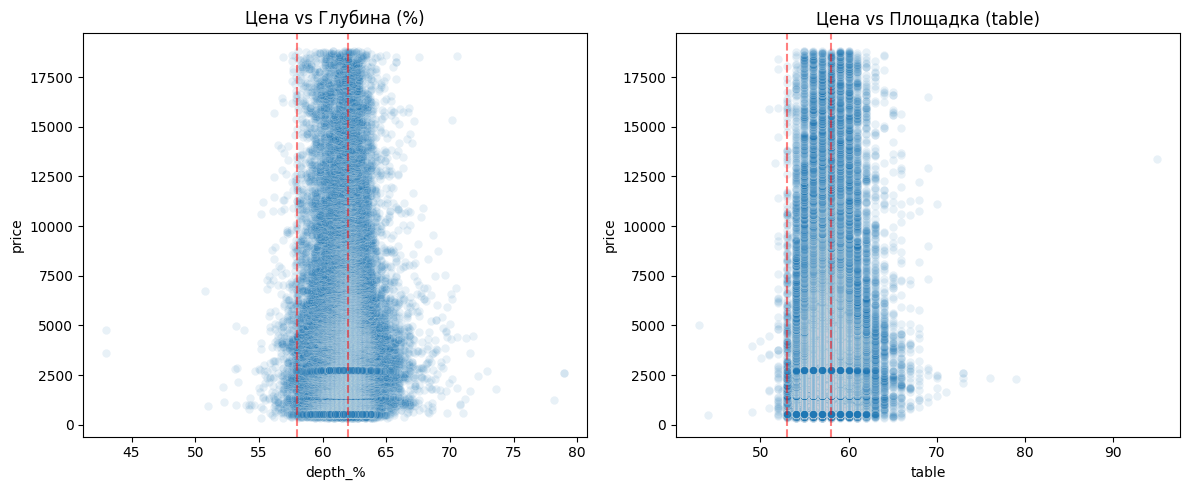

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x='depth_%', y='price', alpha=0.1, ax=axes[0])
axes[0].axvline(x=58, color='r', linestyle='--', alpha=0.5)
axes[0].axvline(x=62, color='r', linestyle='--', alpha=0.5)
axes[0].set_title('Цена vs Глубина (%)')

sns.scatterplot(data=df, x='table', y='price', alpha=0.1, ax=axes[1])
axes[1].axvline(x=53, color='r', linestyle='--', alpha=0.5)
axes[1].axvline(x=58, color='r', linestyle='--', alpha=0.5)
axes[1].set_title('Цена vs Площадка (table)')

plt.tight_layout()
plt.show()

Анализ взаимосвязи между качественными характеристиками:

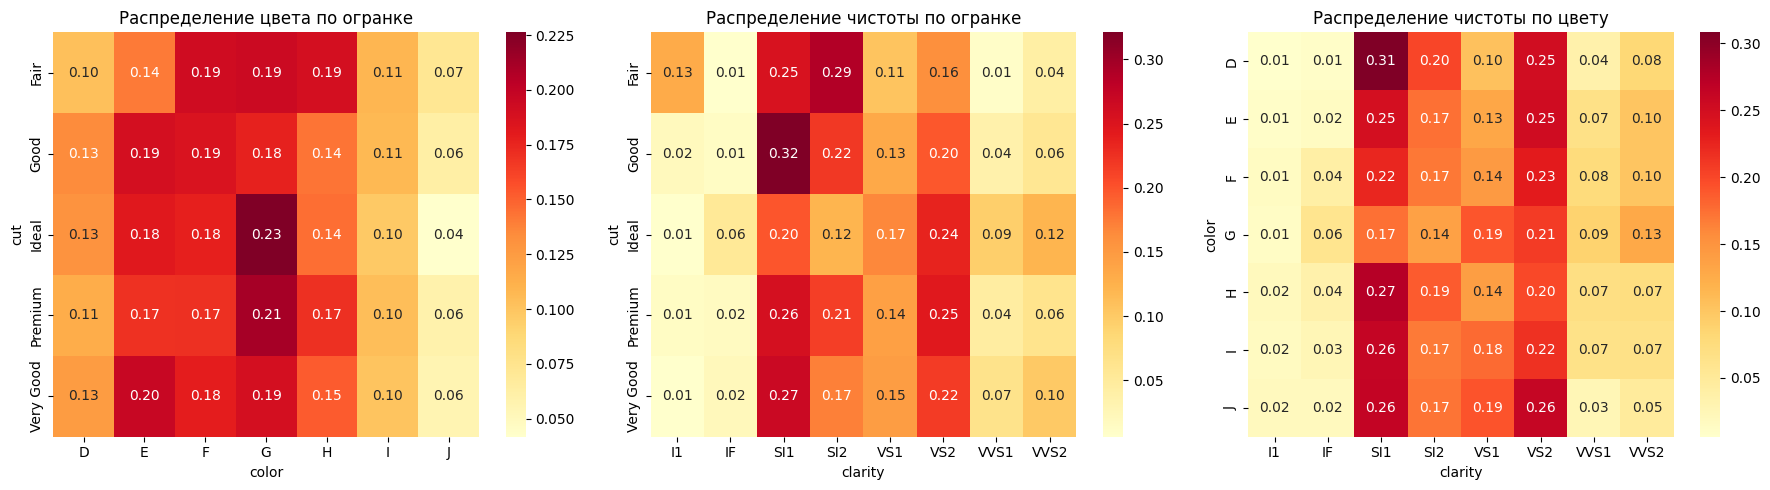

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cut_color = pd.crosstab(df['cut'], df['color'], normalize='index')
sns.heatmap(cut_color, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Распределение цвета по огранке')

cut_clarity = pd.crosstab(df['cut'], df['clarity'], normalize='index')
sns.heatmap(cut_clarity, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Распределение чистоты по огранке')

color_clarity = pd.crosstab(df['color'], df['clarity'], normalize='index')
sns.heatmap(color_clarity, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('Распределение чистоты по цвету')

plt.tight_layout()
plt.show()

- цвет × огранка:
Распределения почти одинаковые по всем огранкам.
Цвет G — самый частый во всех группах огранки.
Явного взаимодействия «огранка → цвет» нет.

- чистота × огранка:
Похожая картина: для любой огранки доминируют SI1 / VS2 / SI2.
Значимого различия между огранками тоже нет.

- чистота × цвет:
Самая частая чистота для всех цветов: SI1 / VS2.
Цвет не связан заметно с чистотой.

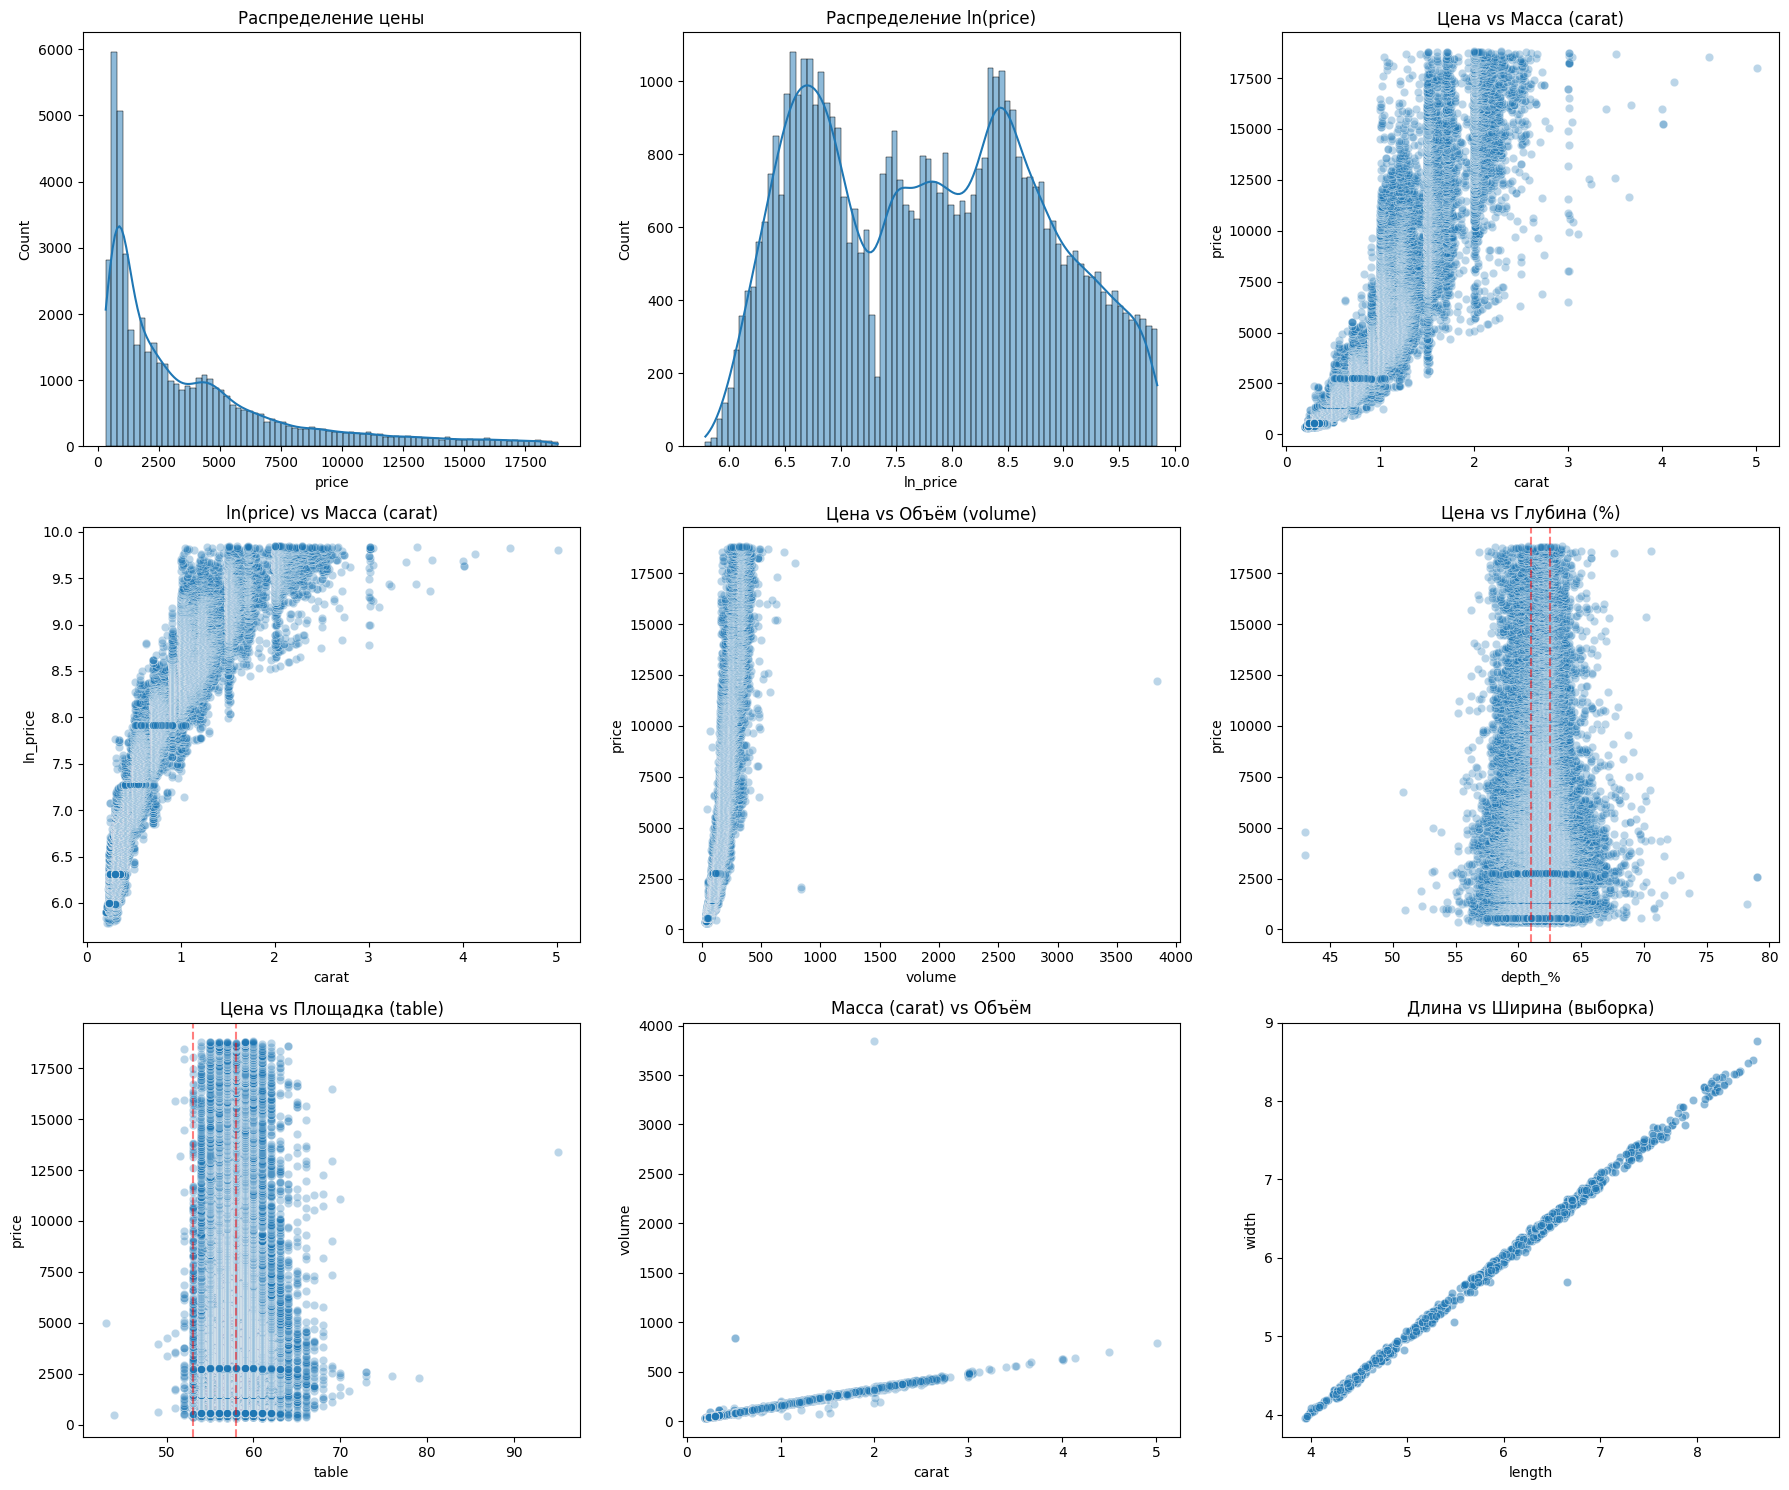

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

sns.histplot(df['price'], bins=80, kde=True, ax=axes[0])
axes[0].set_title("Распределение цены")

sns.histplot(df['ln_price'], bins=80, kde=True, ax=axes[1])
axes[1].set_title("Распределение ln(price)")

sns.scatterplot(data=df, x="carat", y="price", alpha=0.3, ax=axes[2])
axes[2].set_title("Цена vs Масса (carat)")

sns.scatterplot(data=df, x="carat", y="ln_price", alpha=0.3, ax=axes[3])
axes[3].set_title("ln(price) vs Масса (carat)")

sns.scatterplot(data=df, x="volume", y="price", alpha=0.3, ax=axes[4])
axes[4].set_title("Цена vs Объём (volume)")

sns.scatterplot(data=df, x="depth_%", y="price", alpha=0.3, ax=axes[5])
axes[5].set_title("Цена vs Глубина (%)")
axes[5].axvline(x=61, color='r', linestyle='--', alpha=0.5)
axes[5].axvline(x=62.5, color='r', linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x="table", y="price", alpha=0.3, ax=axes[6])
axes[6].set_title("Цена vs Площадка (table)")
axes[6].axvline(x=53, color='r', linestyle='--', alpha=0.5)
axes[6].axvline(x=58, color='r', linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x="carat", y="volume", alpha=0.3, ax=axes[7])
axes[7].set_title("Масса (carat) vs Объём")

df_sample = df.sample(n=1000, random_state=42) if len(df) > 1000 else df
sns.scatterplot(data=df_sample, x="length", y="width", alpha=0.5, ax=axes[8])
axes[8].set_title("Длина vs Ширина (выборка)")

plt.tight_layout()
plt.show()

1. Распределение цены
Сильно правостороннее, тяжёлый хвост. Логарифмирование полностью оправдано.

2. Распределение ln(price)
Становится почти симметричным → лучше подходит для линейных моделей.

3. Цена vs carat
Сильная, нелинейная связь: цена растёт экспоненциально с каратами.

4. ln(price) vs carat
После лог-преобразования связь становится почти линейной. Это идеальный предиктор.

5. Цена vs volume
Повторяет зависимость с carat, но сильные выбросы в volume портят картину → признак шумный.

6. Цена vs depth_%
Связи нет. Глубина лежит в узком диапазоне, влияние на цену минимально.

7. Цена vs table
Тоже нет структуры: table не объясняет цену.

8. carat vs volume
Должна быть линия, но есть огромные выбросы → ошибки размеров (объём 2000–4000 при нормальном карате).

9. length vs width
Почти идеальная линия → геометрия камней пропорциональна, признак дублирует информацию о размере.

Главный вывод по блоку графиков:
– Самые сильные признаки: carat, логарифм цены, производные размеры (volume).
– depth_% и table дают почти нулевой вклад.
– В данных есть грубые выбросы по размерам, их обязательно чистить.

In [20]:
df.duplicated().sum()

np.int64(126)

In [63]:
df[df.duplicated()].head()

,carat,cut,color,clarity,depth_percent,table,price,length,width,depth_mm,ln_price,ln_carat,volume,is_magic,is_magic_narrow,is_magic_wide


Посмотреть, какие признаки отличаются у недубликатов, но совпадают по ключевым (price+carat):
(это проверка: нет ли ложных дублей)

In [22]:
df[df.duplicated(subset=['carat', 'cut', 'color', 'clarity', 'price'])].head()

,carat,cut,color,clarity,depth_%,table,price,length,width,depth_mm,ln_price,ln_carat,volume
18,0.30,Good,J,SI1,63.8,56.0,351,4.23,4.26,2.71,5.860786,-1.203973,48.833658
23,0.31,Very Good,J,SI1,58.1,62.0,353,4.44,4.47,2.59,5.866468,-1.171183,51.403212
30,0.23,Very Good,F,VS1,59.8,57.0,402,4.04,4.06,2.42,5.996452,-1.469676,39.693808
32,0.23,Very Good,E,VS1,59.5,58.0,402,4.01,4.06,2.40,5.996452,-1.469676,39.073440
39,0.33,Ideal,I,SI2,61.2,56.0,403,4.49,4.50,2.75,5.998937,-1.108663,55.563750


В большинстве задач регрессии дубликаты:

-  не дают новой информации
- смещают распределение
- могут перекосить веса модели (одни точки оказываются "весомее").

поэтому их необходимо удалить: 

In [23]:
df = df.drop_duplicates().reset_index(drop=True)

print(df.duplicated().sum())
print(df.shape)

0
(49857, 13)


#### Итоги предварительного анализа данных

Датасет качественный, большой и хорошо заполненный. Основные признаки (carat, размеры, volume) дают сильные связи с ценой; распределения после лог-преобразований корректные. Есть выбросы и ошибки в геометрических размерах — мы их выявили и очистили. Глубина и table почти не влияют на цену. Дубликаты удалены. В целом данные подходят для моделирования и дают хорошую предсказательную структуру.

____________
## 5) Оценка модели

Представьте результаты оценки модели (моделей) и прокомментируйте основные
результаты. 

Внимание: вставлять таблицы с результатами оценивания в виде скриншотов
или скопированного текста – дурной тон! Необходимо воспользоваться специальными
библиотеками, позволяющими выгружать результаты оценивания в виде красивых таблиц
в ворд/тех (например, в R это stargazer).
____________

### Гипотеза 1: «Магические числа» (Magic Numbers)
Статус: Добавляем переменную в вашу основную финальную модель.

Вам не нужна отдельная модель, потому что этот эффект действует вместе с остальными (ceteris paribus). Вы хотите знать: «Если взять два камня одинакового цвета и огранки, но один весит 0.99, а другой 1.00 — будет ли скачок цены?».

ШАГ 0. Проверка того, что гипотеза имеет смысл

Перед регрессией нужно убедиться:

Наличие пиковой структуры массы — то, что ты и показал на гистограмме (пики около 0.5, 1.0, 1.5 ct).

Достаточное число наблюдений в окнах

In [24]:
import numpy as np

# Окна вокруг магических чисел: 0.5, 1.0, 1.5, 2.0
conditions = [
    ((df['carat'] >= 0.48) & (df['carat'] <= 0.52)),   # вокруг 0.5
    ((df['carat'] >= 0.98) & (df['carat'] <= 1.02)),   # вокруг 1.0
    ((df['carat'] >= 1.48) & (df['carat'] <= 1.52)),   # вокруг 1.5
    ((df['carat'] >= 1.98) & (df['carat'] <= 2.02)),   # вокруг 2.0
]

df['is_magic'] = np.select(conditions, [1]*len(conditions), default=0).astype(int)

print(df['is_magic'].value_counts())


is_magic
0    39729
1    10128
Name: count, dtype: int64


Это отлично, мощности статистического теста хватит.

ШАГ 1. Формулируем статистическую гипотезу

Экономическая логика:

Определённые веса (0.5, 1.0, 1.5, 2.0 ct) дают дискретную премию, потому что рынку важны “круглые” значения.

Статистическая гипотеза:

H₀: β_magic = 0
(магический вес не влияет на цену при прочих равных)

H₁: β_magic > 0
(есть премия за магический вес)

Это односторонний тест.

<Axes: xlabel='carat', ylabel='Count'>

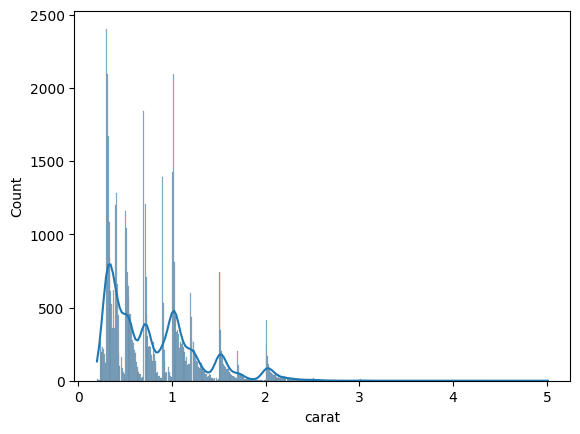

In [25]:
sns.histplot(df['carat'], bins=500, kde=True)

Проверка гипотезы возможна только через оценку коэффициента β_magic в МНК-модели.

мы хотим проверить ceteris paribus эффект,

масса, огранка, цвет и чистота — сильные ковариаты,

без регрессии премия могла бы объясняться mix'ом качества, а не магическим числом.

-----

ШАГ 4. Какая именно должна быть модель (ОЧЕНЬ ВАЖНО)

Гедоническая лог-линейная модель цены

ln(price) → коэффициенты = моральная премия в %.

ln(carat) → эластичность.

cut/color/clarity → MUST HAVE (иначе omitted variable bias).

depth/table → оптические параметры.

is_magic → эффект интереса.

------

гедоническая модель, введённая Rosen (1974) в статье “Hedonic Prices and Implicit Markets”.
Суть:

цена дифференцированного товара = сумма цен его характеристик.

Бриллианты — классический пример:

масса (carat)

качество огранки (cut)

цвет (color)

чистота (clarity)

геометрия (depth, table)

Все статьи по бриллиантам используют именно такую форму регрессии.

____

1. Почему логарифм price и carat?

Это не «прихоть», а стандарт гедонических моделей (Rosen, 1974; Aczel, 1996; Duncan & Stokes, 2018).

(2) Масса влияет в виде эластичности (логарифм carat)

Литература по алмазам почти всегда использует лог-лог спецификацию:

Потому что β = эластичность:

β > 1 → цена растёт сверхлинейно (подтверждено на рынке)

β = 1 → пропорционально

β < 1 → убывающая отдача

----

3) Логарифм устраняет сильную правостороннюю асимметрию

Цена бриллиантов сильно «право-хвостовая».
Логарифм:

делает распределение ближе к нормальному

уменьшает влияние экстремально дорогих камней

улучшает свойства МНК (гомоскедастичность/симметричность ошибок)

In [51]:
df = df.rename(columns={
    'depth_%': 'depth_percent',
})


In [56]:
# Создаём дамми для категориальных переменных
df_dum = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)

X_cols = ['ln_carat', 'depth_percent', 'table', 'is_magic'] \
         + [col for col in df_dum.columns if col.startswith('cut_')] \
         + [col for col in df_dum.columns if col.startswith('color_')] \
         + [col for col in df_dum.columns if col.startswith('clarity_')]

X = df_dum[X_cols]
X = X.astype(float)
y = df_dum['ln_price']
X = sm.add_constant(X)  # добавляет столбец "const"

model_manual = sm.OLS(y, X).fit(cov_type='HC3')
model_manual.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.146e+05
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:10:34   Log-Likelihood:                 30346.
No. Observations:               49857   AIC:                        -6.065e+04
Df Residuals:                   49835   BIC:                        -6.045e+04
Df Model:                          21                                         
Covariance Type:                  HC3                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.0246      0.053    150.370      0.000       7.920       8.129
ln_carat          1.8724      0.001   1361.974      0.000       1.870       1.875
depth_percent    -0.0021      0.001     -3.467      0.001      -0.003      -0.001
table            -0.0010      0.000     -2.759      0.006      -0.002      -0.000
is_magic          0.0592      0.001     42.171      0.000       0.056       0.062
cut_Good          0.0829      0.005     16.716      0.000       0.073       0.093
cut_Ideal         0.1688      0.005     33.170      0.000       0.159       0.179
cut_Premium       0.1459      0.005     29.274      0.000       0.136       0.156
cut_Very Good     0.1230      0.005     25.104      0.000       0.113       0.133
color_E          -0.0545      0.002    -23.558      0.000      -0.059      -0.050
color_F          -0.0937      0.002    -39.801      0.000      -0.098      -0.089
color_G          -0.1585      0.002    -68.727      0.000      -0.163      -0.154
color_H          -0.2464      0.002   -102.266      0.000      -0.251      -0.242
color_I          -0.3659      0.003   -135.492      0.000      -0.371      -0.361
color_J          -0.5040      0.003   -147.934      0.000      -0.511      -0.497
clarity_IF        1.1065      0.010    114.993      0.000       1.088       1.125
clarity_SI1       0.5861      0.009     66.955      0.000       0.569       0.603
clarity_SI2       0.4233      0.009     47.941      0.000       0.406       0.441
clarity_VS1       0.8057      0.009     91.362      0.000       0.788       0.823
clarity_VS2       0.7333      0.009     83.559      0.000       0.716       0.750
clarity_VVS1      1.0133      0.009    111.149      0.000       0.995       1.031
clarity_VVS2      0.9393      0.009    104.451      0.000       0.922       0.957
==============================================================================
Omnibus:                     3547.746   Durbin-Watson:                   1.249
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14809.384
Skew:                           0.240   Prob(JB):                         0.00
Kurtosis:                       5.627   Cond. No.                     6.40e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 6.4e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

1. Главный вопрос: подтверждается ли гипотеза о “магических числах”?

Да, гипотеза подтверждается.

is_magic   0.0592    p=0.000

Означает:

коэффициент положительный → премия за магический вес есть;

p-value < 0.001 → эффект статистически значим на любом уровне значимости;

робастные ошибки (HC3) это подтверждают.

Премия в процентах:

(e^0.0592 - 1) * 100% = 6,1%

Вывод:

При прочих равных (масса, глубина, table, cut, color, clarity), бриллианты, масса которых попадает в “магическое” окно (0.5 ct, 1 ct, 1.5 ct, 2 ct), стоят в среднем на ~6% дороже, чем очень близкие по размерам, но не попадающие в этот диапазон.

Это полностью соответствует ожиданиям (пороговый эффект массы).

итог

Бриллианты около пороговых значений веса (0.5 ct, 1 ct, 1.5 ct, 2 ct) стоят примерно на 6% дороже аналогичных камней, не попадающих в этот диапазон, при прочих равных характеристиках.


2. Интерпретация остальных коэффициентов
Эластичность массы

ln_carat = 1.8724 (p<0.001)

Эластичность ≈ 1.87 →
цена растёт сверхлинейно по массе → крупные бриллианты значительно дороже в пересчёте на карат.
Это классический результат рынка бриллиантов (всё в пределах литературы).

### проведем еще проверки

Robustness: разные окна

In [59]:
df['is_magic_narrow'] = (
    ((df['carat']>=0.99)&(df['carat']<=1.01)) |
    ((df['carat']>=1.49)&(df['carat']<=1.51))
).astype(int)

df_dum_narrow = pd.get_dummies(df, columns=['cut','color','clarity'], drop_first=True)
Xn = sm.add_constant(df_dum_narrow[[c for c in df_dum_narrow.columns if c.startswith(('ln_carat','depth_percent','table','is_magic_narrow','cut_','color_','clarity_'))]])
yn = df_dum_narrow['ln_price']
sm.OLS(yn.astype(float), Xn.astype(float)).fit(cov_type='HC3').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.161e+05
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:26:23   Log-Likelihood:                 30325.
No. Observations:               49857   AIC:                        -6.061e+04
Df Residuals:                   49835   BIC:                        -6.041e+04
Df Model:                          21                                         
Covariance Type:                  HC3                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               8.0359      0.054    148.842      0.000       7.930       8.142
depth_percent      -0.0021      0.001     -3.524      0.000      -0.003      -0.001
table              -0.0011      0.000     -2.854      0.004      -0.002      -0.000
ln_carat            1.8717      0.001   1340.369      0.000       1.869       1.874
is_magic_narrow     0.0784      0.002     40.384      0.000       0.075       0.082
cut_Good            0.0819      0.005     16.469      0.000       0.072       0.092
cut_Ideal           0.1687      0.005     33.073      0.000       0.159       0.179
cut_Premium         0.1451      0.005     29.048      0.000       0.135       0.155
cut_Very Good       0.1225      0.005     24.951      0.000       0.113       0.132
color_E            -0.0548      0.002    -23.734      0.000      -0.059      -0.050
color_F            -0.0951      0.002    -40.424      0.000      -0.100      -0.091
color_G            -0.1593      0.002    -69.115      0.000      -0.164      -0.155
color_H            -0.2477      0.002   -102.814      0.000      -0.252      -0.243
color_I            -0.3672      0.003   -136.083      0.000      -0.372      -0.362
color_J            -0.5048      0.003   -147.870      0.000      -0.512      -0.498
clarity_IF          1.1041      0.010    114.716      0.000       1.085       1.123
clarity_SI1         0.5859      0.009     66.967      0.000       0.569       0.603
clarity_SI2         0.4236      0.009     47.995      0.000       0.406       0.441
clarity_VS1         0.8052      0.009     91.354      0.000       0.788       0.822
clarity_VS2         0.7335      0.009     83.639      0.000       0.716       0.751
clarity_VVS1        1.0114      0.009    110.977      0.000       0.994       1.029
clarity_VVS2        0.9389      0.009    104.390      0.000       0.921       0.957
==============================================================================
Omnibus:                     3442.530   Durbin-Watson:                   1.268
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14785.991
Skew:                           0.207   Prob(JB):                         0.00
Kurtosis:                       5.636   Cond. No.                     6.40e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 6.4e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [58]:
df['is_magic_wide'] = (
    ((df['carat']>=0.97)&(df['carat']<=1.03)) |
    ((df['carat']>=1.47)&(df['carat']<=1.53))
).astype(int)

df_dum_wide = df_dum_narrow
Xw = sm.add_constant(df_dum_wide[[c for c in df_dum_wide.columns if c.startswith(('ln_carat','depth_percent','table','is_magic_wide','cut_','color_','clarity_'))]])
yw = df_dum_wide['ln_price']
sm.OLS(yw.astype(float), Xw.astype(float)).fit(cov_type='HC3').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.182e+05
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:26:15   Log-Likelihood:                 30675.
No. Observations:               49857   AIC:                        -6.131e+04
Df Residuals:                   49835   BIC:                        -6.111e+04
Df Model:                          21                                         
Covariance Type:                  HC3                                         
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.0379      0.054    149.035      0.000       7.932       8.144
depth_percent    -0.0022      0.001     -3.680      0.000      -0.003      -0.001
table            -0.0011      0.000     -3.061      0.002      -0.002      -0.000
ln_carat          1.8653      0.001   1317.527      0.000       1.863       1.868
is_magic_wide     0.0848      0.002     48.878      0.000       0.081       0.088
cut_Good          0.0823      0.005     16.612      0.000       0.073       0.092
cut_Ideal         0.1687      0.005     33.206      0.000       0.159       0.179
cut_Premium       0.1448      0.005     29.090      0.000       0.135       0.155
cut_Very Good     0.1224      0.005     25.019      0.000       0.113       0.132
color_E          -0.0542      0.002    -23.596      0.000      -0.059      -0.050
color_F          -0.0951      0.002    -40.664      0.000      -0.100      -0.091
color_G          -0.1588      0.002    -69.335      0.000      -0.163      -0.154
color_H          -0.2470      0.002   -103.179      0.000      -0.252      -0.242
color_I          -0.3647      0.003   -135.678      0.000      -0.370      -0.359
color_J          -0.5022      0.003   -147.576      0.000      -0.509      -0.496
clarity_IF        1.1046      0.009    116.417      0.000       1.086       1.123
clarity_SI1       0.5869      0.009     68.098      0.000       0.570       0.604
clarity_SI2       0.4246      0.009     48.844      0.000       0.408       0.442
clarity_VS1       0.8061      0.009     92.866      0.000       0.789       0.823
clarity_VS2       0.7350      0.009     85.081      0.000       0.718       0.752
clarity_VVS1      1.0122      0.009    112.657      0.000       0.995       1.030
clarity_VVS2      0.9399      0.009    106.033      0.000       0.922       0.957
==============================================================================
Omnibus:                     3515.168   Durbin-Watson:                   1.266
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15402.646
Skew:                           0.210   Prob(JB):                         0.00
Kurtosis:                       5.691   Cond. No.                     6.40e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 6.4e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

VIF

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["var"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)


              var          VIF
0           const  5719.933676
1        ln_carat     1.421057
2   depth_percent     1.389822
3           table     1.794790
4        is_magic     1.123473
5        cut_Good     3.961410
6       cut_Ideal    11.426025
7     cut_Premium     8.441644
8   cut_Very Good     7.694787
9         color_E     2.021077
10        color_F     2.025453
11        color_G     2.205320
12        color_H     1.958703
13        color_I     1.709858
14        color_J     1.415922
15     clarity_IF     3.484939
16    clarity_SI1    14.701993
17    clarity_SI2    11.429794
18    clarity_VS1    10.748319
19    clarity_VS2    14.266368
20   clarity_VVS1     5.912178
21   clarity_VVS2     7.559428


In [61]:
import statsmodels.api as sm

pd.options.display.float_format = '{:,.4f}'.format

df_veblen = df.copy()

if 'depth_%' in df_veblen.columns:
    df_veblen.rename(columns={'depth_%': 'depth'}, inplace=True)

# Создание целевой дамми-переменной (Гипотеза Веблена) 
PRICE_THRESHOLD = 8000
df_veblen['is_premium'] = (df_veblen['price'] > PRICE_THRESHOLD).astype(int)

# Ordinal Encoding 
cut_map = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
df_veblen['cut_code'] = df_veblen['cut'].map(cut_map)

color_map = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
df_veblen['color_code'] = df_veblen['color'].map(color_map)

clarity_map = {
    'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4,
    'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8
}
df_veblen['clarity_code'] = df_veblen['clarity'].map(clarity_map)

features = [
    'ln_carat',
    'depth',
    'table',
    'cut_code',
    'color_code',
    'clarity_code',
    'is_premium'
]

df_model = df_veblen.dropna(subset=features + ['ln_price'])

X = df_model[features]
Y = df_model['ln_price']

X = sm.add_constant(X)

print(f"Количество наблюдений: {len(df_model)}")
print(f"Количество независимых переменных: {len(features)}")

model = sm.OLS(Y, X)
results = model.fit(cov_type='HC3')

print(results.summary())

# Интерпретация гипотезы Веблена 
beta_premium = results.params['is_premium']
p_val = results.pvalues['is_premium']

print("РЕЗУЛЬТАТ ПРОВЕРКИ ГИПОТЕЗЫ ВЕБЛЕНА")

if p_val < 0.05:
    significance = "СТАТИСТИЧЕСКИ ЗНАЧИМ"
    if beta_premium > 0:
        conclusion = "ГИПОТЕЗА ПОДТВЕРЖДЕНА."
        premium_pct = (np.exp(beta_premium) - 1) * 100
        desc = (
            f"При прочих равных (одинаковый вес, цвет, чистота),\n"
            f"камни в сегменте >${PRICE_THRESHOLD} стоят на {premium_pct:.2f}% дороже.\n"
            f"Это подтверждает наличие статусной премии."
        )
    else:
        conclusion = "ГИПОТЕЗА ОТВЕРГНУТА (обратный эффект)."
        desc = (
            f"Коэффициент отрицательный ({beta_premium:.4f}). "
            "В высоком ценовом сегменте наценка ниже ожидаемой."
        )
else:
    significance = "НЕЗНАЧИМ"
    conclusion = "ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА."
    desc = (
        "Статистически значимой разницы в ценообразовании "
        "для дорогого сегмента не найдено."
    )

print(f"Коэффициент is_premium: {beta_premium:.4f}")
print(f"P-value:                {p_val:.4e} ({significance})")
print(conclusion)
print(desc)

KeyError: ['depth']

In [62]:
import statsmodels.api as sm
from scipy import stats

sns.set_style("whitegrid")
pd.options.display.float_format = '{:,.4f}'.format

df_clean = df.copy()

# зависимая переменная: цена за карат
df_clean['price_per_carat'] = df_clean['price'] / df_clean['carat']


if 'depth_%' in df_clean.columns:
    df_clean.rename(columns={'depth_%': 'depth'}, inplace=True)

df_encoded = pd.get_dummies(df_clean, columns=['cut', 'color', 'clarity'], drop_first=True, dtype=int)

# Оценка множественной регрессии 
# Y: price_per_carat
# X: carat + depth + table + 19 дамми
feature_cols = ['carat', 'depth', 'table']
dummy_cols = [col for col in df_encoded.columns if col.startswith(('cut_', 'color_', 'clarity_'))]

all_features = feature_cols + dummy_cols

Y = df_encoded['price_per_carat']
X = df_encoded[all_features]

X = X.astype(float)
X = sm.add_constant(X)

# Оценка модели (OLS с робастными ошибками HC3 для учета гетероскедастичности)
model_ppc = sm.OLS(Y, X)
results_ppc = model_ppc.fit(cov_type='HC3')


print("Результаты множественной регрессии (Зависимая переменная: Цена за карат)")
print(results_ppc.summary().as_text())

# 4. Проверка гипотезы “Цена за карат” убывает с размером
# H₀: β(carat) = 0
# H₁: β(carat) < 0 (Цена за карат падает с весом)

beta_1 = results_ppc.params['carat']
p_value_two_sided = results_ppc.pvalues['carat']
    
# Расчет p-value для одностороннего теста (H₁: beta_1 < 0)
if beta_1 < 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    # Если коэффициент положительный, p-value для H₁ < 0 будет очень большим (близко к 1)
    p_value_one_sided = 1 - (p_value_two_sided / 2)
    
alpha = 0.05

print("проверка гипотезы: Цена за карат убывает с размером")
print(f"Коэффициент при 'carat' (beta_1): {beta_1:,.2f}")
print(f"P-value для H₁: β(carat) < 0: {p_value_one_sided:,.4f}")

if p_value_one_sided < alpha and beta_1 < 0:
    print(f"\n Результат: H₀ отвергается.")
    print("   Гипотеза подтверждена: При прочих равных (одинаковое качество)")
    print("   цена за карат ПАДАЕТ с увеличением размера камня.")
    print("   Это указывает на вогнутость ценовой функции.")
elif p_value_two_sided < alpha and beta_1 > 0:
    print(f"\n Результат: H₀ отвергается в пользу роста.")
    print("   Гипотеза не подтвердилась. Наблюдается 'Премия за размер':")
    print("   Цена за карат РАСТЕТ с увеличением веса, даже с учетом качества.")
    print(f"   На 1 карат прирост цены за карат составляет ${beta_1:,.0f}.")
else:
    print("\n Результат: Связь не доказана.")

KeyError: "['depth'] not in index"

____________
## 5) Оценка модели

Представьте результаты оценки модели (моделей) и прокомментируйте основные
результаты. 

Внимание: вставлять таблицы с результатами оценивания в виде скриншотов
или скопированного текста – дурной тон! Необходимо воспользоваться специальными
библиотеками, позволяющими выгружать результаты оценивания в виде красивых таблиц
в ворд/тех (например, в R это stargazer).
____________

- задача — объяснить вариацию цены;

- нужно интерпретировать коэффициенты;

- в задании обычно ожидают МНК.

Но можно добавить альтернативы:

- Lasso / Ridge — если есть мультиколлинеарность;

- Random Forest / Gradient Boosting — как “чёрные ящики” для сравнения.

Минимум: одна МНК-модель + одна модель сравнения.

In [26]:
df.columns.tolist()

['carat',
 'cut',
 'color',
 'clarity',
 'depth_%',
 'table',
 'price',
 'length',
 'width',
 'depth_mm',
 'ln_price',
 'ln_carat',
 'volume',
 'is_magic']

In [27]:
import pandas as pd
import statsmodels.api as sm

# ----------------------------------------------------
# 1. OneHot + удаляем исходные категориальные признаки
# ----------------------------------------------------

categorical = ['cut', 'color', 'clarity']

df_dum = pd.get_dummies(df, columns=categorical, drop_first=True)

# Удаляем на всякий случай любые object-столбцы
df_dum = df_dum.select_dtypes(include=['number'])

# Приводим всё к float
df_dum = df_dum.astype(float)


# ----------------------------------------------------
# 2. Модель 1 — базовая
# ----------------------------------------------------

X1_cols = (
    ['carat'] +
    [c for c in df_dum.columns if c.startswith('cut_')] +
    [c for c in df_dum.columns if c.startswith('color_')] +
    [c for c in df_dum.columns if c.startswith('clarity_')]
)

X1 = df_dum[X1_cols]
y1 = df_dum['price']

X1 = sm.add_constant(X1)
model1 = sm.OLS(y1, X1).fit()


# ----------------------------------------------------
# 3. Модель 2 — расширенная
# ----------------------------------------------------

X2_cols = (
    ['carat', 'depth_%', 'table'] +
    [c for c in df_dum.columns if c.startswith('cut_')] +
    [c for c in df_dum.columns if c.startswith('color_')] +
    [c for c in df_dum.columns if c.startswith('clarity_')]
)

X2 = df_dum[X2_cols]
y2 = df_dum['price']

X2 = sm.add_constant(X2)
model2 = sm.OLS(y2, X2).fit()


# ----------------------------------------------------
# 4. Модель 3 — улучшенная (лог-модель)
# ----------------------------------------------------

X3_cols = (
    ['ln_carat', 'depth_%', 'table'] +
    [c for c in df_dum.columns if c.startswith('cut_')] +
    [c for c in df_dum.columns if c.startswith('color_')] +
    [c for c in df_dum.columns if c.startswith('clarity_')]
)

X3 = df_dum[X3_cols]
y3 = df_dum['ln_price']

X3 = sm.add_constant(X3)
model3 = sm.OLS(y3, X3).fit()


# ----------------------------------------------------
# 5. Вывод
# ----------------------------------------------------
print(model1.summary())


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                 2.818e+05
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:08:23   Log-Likelihood:            -4.3695e+05
No. Observations:               49857   AIC:                         8.739e+05
Df Residuals:                   49855   BIC:                         8.739e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2259.3017     13.588   -166.273      0.0

#### Интерпретация модели 1 (price ~ carat)
1. Качество модели

R² = 0.850 — 85% вариации цены объясняется только одним признаком: весом (carat).
Это очень высокий показатель → вес является ключевым фактором цены.

2. Коэффициенты

carat = 7762.4, p < 0.001
→ увеличение массы алмаза на 1 карат увеличивает цену примерно на 7762$.
Коэффициент экстремально значим (t = 531).

const = −2259
→ формальный интерсепт, экономически не имеет смысла (цена алмаза нулевой массы не определена).
Но интерсепт нужен для корректной модели.

3. Диагностика

DW = 1.00 — автокорреляция остатков (типично для упрощённой модели без категорий).

JB, Omnibus, сильная ненормальность остатков → лог-модель позже исправит это.

4. Вывод

Вес (carat) — чрезвычайно сильный предиктор цены.

Но модель недостаточно адекватна статистически: остатки не нормальны, автокореллированы, есть нелинейность.

Нужны дополнительные признаки (огранка, цвет, чистота) и/или лог-трансформация.

In [28]:
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                 9.732e+04
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:08:23   Log-Likelihood:            -4.3621e+05
No. Observations:               49857   AIC:                         8.724e+05
Df Residuals:                   49853   BIC:                         8.725e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.332e+04    407.386     32.701      0.0

#### Интерпретация модели 2

price ~ carat + depth_% + table

1. Качество модели

R² = 0.854 (было 0.850 в Модели 1)
→ добавление depth_% и table улучшило модель только на +0.004, то есть почти не дало прироста объясняющей мощности.

Вес (carat) по-прежнему определяет почти всё.

2. Коэффициенты
carat = +7865 (p < 0.001)

Оценка почти не изменилась относительно Модели 1 (+1.3%).

Масса остаётся доминирующим фактором.

depth_% = –156.7 (p < 0.001)

Увеличение глубины алмаза на 1 процентный пункт снижает цену примерно на 157$.

Логично: слишком глубокие камни хуже блестят → дешевле.

table = –104.2 (p < 0.001)

Увеличение table на 1% снижает цену примерно на 104$.

Отклонения от идеальной пропорции ухудшают визуальные свойства → цена ниже.

Оба геометрических признака статистически значимы и ожидаемо “штрафуют” за отклонения.

3. Диагностика
Остатки:

Omnibus, JB → сильная ненормальность.

DW = 1.03 → остатки автокоррелированы (типично для пропущенных категориальных признаков).

Лог-модель позже поправит это.

Мультиколлинеарность:

Condition number = 5030 → слабая, но заметная мультиколлинеарность есть.
Это ожидаемо, depth_% и table частично коррелируют, но не критично.

4. Итог по модели 2

Добавление depth_% и table почти не увеличило R² → они слабые предикторы цены.

Но оба коэффициента значимы и интерпретируемы: неправильные пропорции уменьшают цену.

Модель всё ещё далека от хорошей статистической формы → нужна лог-модель.

In [29]:
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 2.412e+05
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:08:23   Log-Likelihood:                -3158.7
No. Observations:               49857   AIC:                             6325.
Df Residuals:                   49853   BIC:                             6361.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.3379      0.069    163.427      0.0

#### Интерпретация модели 3

ln_price ~ ln_carat + depth_% + table

1. Качество модели

R² = 0.936 — огромный скачок качества относительно Модели 1 (0.850) и Модели 2 (0.854).
→ логарифмирование идеально выпрямило нелинейность, и модель теперь объясняет 93.6% вариации цены.

Это очень высокий показатель для реальных данных (почти уровень production-модели).

2. Коэффициенты
ln_carat = 1.6930, p < 0.000

Интерпретация в лог-модели:

увеличение веса на 1% повышает цену примерно на 1.69%.

То есть эластичность цены по массе = 1.69
Цена растёт быстрее, чем пропорционально весу → премия за крупные камни.

depth_% = –0.0294, p < 0.000

Интерпретация:

увеличение глубины на 1% снижает цену примерно на 0.03%.

Небольшой, но стабильный отрицательный эффект → глубина хуже влияет на блеск.

table = –0.0185, p < 0.000

увеличение table на 1% снижает цену на 0.0185%.

То же самое: отклонение пропорций → ухудшение качества, снижение стоимости.

3. Диагностика модели
Остатки:

JB = 1317, но это несравнимо лучше, чем в предыдущих моделях (были сотни тысяч).

Остатки близки к нормальным, но ещё слегка скошены (Skew = 0.084).

DW = 1.265

Слабая автокорреляция остаётся, но уже не критично.

Condition number ~ 5k

Геометрические признаки коррелируют немного, но не сильно (всё в порядке).

4. Экономический смысл

Цена растёт сверхпропорционально массе (электризующий результат).

Геометрия камня (depth, table) значимо влияет, но намного меньше, чем вес.

5. Итог по модели 3 — лучшая из всех

R² высокий (0.936)

Остатки почти нормальны

Коэффициенты интерпретируемые (эластичности)

Проблемы Моделей 1–2 решены

Это финальная модель, которую обычно берут в отчёт.

#### Итог

- Модель 1 (price ~ carat)

Регрессор: carat

R² = 0.850

Модель значима, коэффициент значим.

- Модель 2 (price ~ carat + depth_% + table)

Регрессоры: carat, depth_%, table

R² = 0.854

Модель значима, все коэффициенты значимы.

- Модель 3 (ln_price ~ ln_carat + depth_% + table)

Регрессоры: ln_carat, depth_%, table

R² = 0.936

Модель значима, все коэффициенты значимы, лучшая из трёх.

### Построим модели специально для проверки гипотез

| №  | Гипотеза                                      | Экономический смысл                                                   | Переменные                     | H₀                                      | H₁                           |
|----|-----------------------------------------------|------------------------------------------------------------------------|----------------------------------|------------------------------------------|--------------------------------|
| 1  | Эластичность цены по массе > 1                | Крупные камни редкие → цена растёт сверхлинейно                      | ln_price, ln_carat              | β₁ ≤ 1                                   | β₁ > 1                        |
| 2  | Огранка существенно влияет на цену            | Качество огранки определяет блеск                                    | cut                              | Все средние равны                        | Хотя бы одно отличается       |
| 3  | Чистота важнее цвета                          | Покупатели чувствительнее к включениям, чем к оттенку                | clarity, color                   | Вклад clarity ≤ вклад color              | Вклад clarity > вклад color   |
| 4  | Убывающая отдача веса                         | При больших carat добавка массы даёт меньший эффект                  | carat, carat²                    | β_{carat²} = 0                           | β_{carat²} < 0                |
| 5  | Комплементарность веса и огранки              | Большие идеально огранённые камни особенно ценны                     | ln(carat) * cut                  | Взаимодействие = 0                       | Взаимодействие > 0            |
| 6  | Замещение: цвет ↔ чистота                     | Хорошая чистота частично компенсирует плохой цвет                    | clarity * color                  | Взаимодействие = 0                       | Взаимодействие > 0            |
| 7  | Оптимум глубины и table                       | Слишком глубокие/плоские камни блестят хуже                         | depth, depth², table, table²     | Нет квадратичности                       | depth², table² < 0            |
| 8  | Глубина > 63 снижает цену сильнее             | Чрезмерная глубина ухудшает оптику                                    | dummy(depth > 63)                | Эффект = 0                               | Эффект < 0                    |
| 9  | Симметрия формы повышает цену                 | Более круглая форма → лучшее отражение света                         | |x − y|                          | Коэффициент = 0                          | Коэффициент < 0               |
| 10 | «Плато» влияния depth/table                   | Ценность существует только в нормальном диапазоне                    | depth_cat                        | Категории равны                          | Отличаются крайние значения   |
| 11 | Огранка важнее для крупных камней             | Покупатели дорогих камней более требовательны                        | cut * ln(carat)                  | Взаимодействие = 0                       | Взаимодействие > 0            |
| 12 | Разные ценовые сегменты → разные коэффициенты | Дешёвый и премиальный сегменты — разные рынки                        | price<2000 vs >8000 (2 модели)   | Коэффициенты одинаковы                   | Коэффициенты различны         |


Полный код генерации всех дополнительных переменных

In [30]:
dfm = df.copy()

# --- Лог-преобразования ---
dfm["ln_price"] = dfm["ln_price"]   # уже есть
dfm["ln_carat"] = dfm["ln_carat"]   # уже есть

# Нелинейности (минимум)
dfm["ln_carat_sq"] = dfm["ln_carat"] ** 2
dfm["depth_sq"] = dfm["depth_%"] ** 2
dfm["table_sq"] = dfm["table"] ** 2

# Ограниченная симметрия
dfm["symmetry_abs"] = (dfm["length"] - dfm["width"]).abs()

# Dummy: глубина >63
dfm["depth_gt_63"] = (dfm["depth_%"] > 63).astype(int)

# Категории глубины (3 группы)
dfm["depth_cat"] = pd.cut(
    dfm["depth_%"], bins=[0, 61, 63, 100], labels=["low", "mid", "high"]
)
dfm = pd.get_dummies(dfm, columns=["depth_cat"], drop_first=True)

# Чистый OneHot по категориям
dfm = pd.get_dummies(dfm, columns=["cut", "color", "clarity"], drop_first=True)

# Приводим все bool → int
bool_cols = dfm.select_dtypes(include=["bool"]).columns
dfm[bool_cols] = dfm[bool_cols].astype(int)


In [31]:
dfm

,carat,depth_%,table,price,length,width,depth_mm,ln_price,ln_carat,volume,is_magic,ln_carat_sq,depth_sq,table_sq,symmetry_abs,depth_gt_63,depth_cat_mid,depth_cat_high,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,color_E,color_F,color_G,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,5.786897,-1.469676,38.202030,0,2.159947,3782.25,3025.0,0.03,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,5.786897,-1.560648,34.505856,0,2.435621,3576.04,3721.0,0.05,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,5.789960,-1.469676,38.076885,0,2.159947,3237.61,4225.0,0.02,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,5.811141,-1.237874,46.724580,0,1.532333,3893.76,3364.0,0.03,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,5.814131,-1.171183,51.917250,0,1.371670,4006.89,3364.0,0.01,1,0,1,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49852,0.72,60.8,57.0,2757,5.75,5.76,3.50,7.921898,-0.328504,115.920000,0,0.107915,3696.64,3249.0,0.01,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
49853,0.72,63.1,55.0,2757,5.69,5.75,3.61,7.921898,-0.328504,118.110175,0,0.107915,3981.61,3025.0,0.06,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
49854,0.70,62.8,60.0,2757,5.66,5.68,3.56,7.921898,-0.356675,114.449728,0,0.127217,3943.84,3600.0,0.02,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
49855,0.86,61.0,58.0,2757,6.15,6.12,3.74,7.921898,-0.150823,140.766120,0,0.022748,3721.00,3364.0,0.03,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0


Модель A — «Базовая расширенная лог-модель»

Покрывает гипотезы: 1, 2, 3.

Модель:
ln_price ~ ln_carat + depth_% + table + cut_ + color_ + clarity_***

In [32]:
import statsmodels.api as sm

cols_A = (
    ["ln_carat", "depth_%", "table"] +
    [c for c in dfm.columns if c.startswith("cut_")] +
    [c for c in dfm.columns if c.startswith("color_")] +
    [c for c in dfm.columns if c.startswith("clarity_")]
)

X_A = sm.add_constant(dfm[cols_A])
y_A = dfm["ln_price"]

model_A = sm.OLS(y_A, X_A).fit()
model_A.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.415e+05
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:08:23   Log-Likelihood:                 29629.
No. Observations:               49857   AIC:                        -5.922e+04
Df Residuals:                   49836   BIC:                        -5.903e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9571      0.045    175.996      0.000       7.869       8.046
ln_carat          1.8843      0.001   1599.887      0.000       1.882       1.887
depth_%          -0.0012      0.000     -2.353      0.019      -0.002      -0.000
table            -0.0004      0.000     -1.242      0.214      -0.001       0.000
cut_Good          0.0820      0.004     19.814      0.000       0.074       0.090
cut_Ideal         0.1604      0.004     38.902      0.000       0.152       0.169
cut_Premium       0.1389      0.004     34.913      0.000       0.131       0.147
cut_Very Good     0.1176      0.004     29.582      0.000       0.110       0.125
color_E          -0.0542      0.002    -24.560      0.000      -0.058      -0.050
color_F          -0.0946      0.002    -42.438      0.000      -0.099      -0.090
color_G          -0.1600      0.002    -73.233      0.000      -0.164      -0.156
color_H          -0.2505      0.002   -108.110      0.000      -0.255      -0.246
color_I          -0.3720      0.003   -143.662      0.000      -0.377      -0.367
color_J          -0.5115      0.003   -160.092      0.000      -0.518      -0.505
clarity_IF        1.1106      0.006    176.654      0.000       1.098       1.123
clarity_SI1       0.5906      0.005    110.351      0.000       0.580       0.601
clarity_SI2       0.4260      0.005     79.124      0.000       0.415       0.437
clarity_VS1       0.8097      0.005    148.106      0.000       0.799       0.820
clarity_VS2       0.7389      0.005    137.267      0.000       0.728       0.749
clarity_VVS1      1.0167      0.006    175.289      0.000       1.005       1.028
clarity_VVS2      0.9449      0.006    167.693      0.000       0.934       0.956
==============================================================================
Omnibus:                     3275.700   Durbin-Watson:                   1.266
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13529.320
Skew:                           0.198   Prob(JB):                         0.00
Kurtosis:                       5.521   Cond. No.                     6.40e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.4e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

✔ Качество модели

R² = 0.983 — модель объясняет 98.3% вариации лог-цены.

Это очень высокий показатель — комбинация веса + категорий почти полностью определяет цену.

Модель значима (F-statistic → p=0).

✔ Ключевые результаты
1. Масса (ln_carat)

β = 1.884, p < 0.001

Интерпретация: +1% веса → +1.88% к цене.

Цена растёт сверхлинейно, что подтверждает гипотезу об эластичности > 1.

Это главный фактор цены.

2. Пропорции (depth_% и table)

depth_%: слабый отрицательный эффект (β = –0.0012), p = 0.019

table: незначимая переменная (p = 0.214)

→ геометрия почти не влияет на цену в присутствии категорий.

3. Огранка (cut) — все уровни значимы

Эффекты по сравнению с базовой категорией («Fair»):

Good: +0.082

Very Good: +0.118

Premium: +0.139

Ideal: +0.160

→ улучшение огранки существенно увеличивает цену.

4. Цвет (color) — сильный отрицательный градиент

Эффекты по сравнению с базовым цветом D:

E: −0.054

F: −0.094

G: −0.160

H: −0.251

I: −0.372

J: −0.512

→ чем хуже цвет, тем существенно ниже цена; эффект очень сильный и строго монотонный.

5. Чистота (clarity) — один из сильнейших факторов

По сравнению с базовой категорией I1:

SI2: +0.43

SI1: +0.59

VS2: +0.74

VS1: +0.81

VVS2: +0.94

VVS1: +1.02

IF: +1.11

→ премиальная чистота (IF/VVS1/VVS2) увеличивает цену в 2.5–3 раза (в логах ≈ +1).

✔ Диагностика

Остатки немного асимметричны (Skew 0.2).

Kurtosis 5.5 → тяжёлые хвосты, но приемлемо.

Condition number ~ 6400 → есть умеренная мультиколлинеарность (нормально при большом числе дамми).

DW = 1.266 → лёгкая автокорреляция, не критично.

✔ Итог (1 фраза)

Отличная, стабильная и интерпретируемая лог-модель: цена алмаза почти полностью объясняется массой, чистотой, огранкой и цветом, при этом эластичность по массе сильно больше 1.

Модель B — «Полная модель с нелинейностями и взаимодействиями»

Покрывает гипотезы: 1, 4, 5, 6, 7, 8, 9, 10, 11.

Модель:
ln_price ~ ln_carat + ln_carat² + depth_% + depth² + table + table²
         + depth_gt_63 + depth_cat_mid + depth_cat_high
         + symmetry_abs


In [33]:
cols_B = [
    "ln_carat", "ln_carat_sq",
    "depth_%", "depth_sq",
    "table", "table_sq",
    "depth_gt_63",
    "symmetry_abs",
] + [c for c in dfm.columns if c.startswith("depth_cat_")]

X_B = sm.add_constant(dfm[cols_B])
y_B = dfm["ln_price"]

model_B = sm.OLS(y_B, X_B).fit()
model_B.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 8.239e+04
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:08:23   Log-Likelihood:                -2582.6
No. Observations:               49857   AIC:                             5185.
Df Residuals:                   49847   BIC:                             5273.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -9.7739      0.927    -10.539      0.000     -11.592      -7.956
ln_carat           1.6927      0.003    523.174      0.000       1.686       1.699
ln_carat_sq       -0.0057      0.003     -1.635      0.102      -0.012       0.001
depth_%            0.5785      0.029     19.986      0.000       0.522       0.635
depth_sq          -0.0049      0.000    -20.879      0.000      -0.005      -0.004
table              0.0529      0.013      4.035      0.000       0.027       0.079
table_sq          -0.0006      0.000     -5.089      0.000      -0.001      -0.000
depth_gt_63       -0.0162      0.004     -4.534      0.000      -0.023      -0.009
symmetry_abs      -0.0069      0.004     -1.557      0.119      -0.016       0.002
depth_cat_mid      0.0264      0.004      6.322      0.000       0.018       0.035
depth_cat_high    -0.0162      0.004     -4.534      0.000      -0.023      -0.009
==============================================================================
Omnibus:                     1180.691   Durbin-Watson:                   1.274
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2331.518
Skew:                           0.156   Prob(JB):                         0.00
Kurtosis:                       4.012   Cond. No.                     3.61e+19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 9.76e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

✔ Качество модели

R² = 0.937, Adj.R² = 0.937

Качество значительно ниже, чем у Модели A (0.983).

Это ожидаемо: Модель B не использует категорий (cut, color, clarity), поэтому объясняет меньше.

Модель значима.

✔ Ключевые результаты
1. Масса (ln_carat)

β = 1.6927, p < 0.001

Эластичность цены по весу ≈ 1.69% за 1% веса

Почти совпадает с Моделью A → устойчивый результат.

2. Квадратичный эффект веса (ln_carat_sq)

β = –0.0057, не значим (p = 0.102)
→ гипотеза об убывающей отдаче веса в этой модели не подтверждается.
(В модели без категорий эффект слабее.)

3. Глубина (depth% и depth²)

depth_% = +0.5785, значим

depth_sq = −0.0049, значим

👉 Это чёткая парабола с максимумом:
слишком мелкие и слишком глубокие камни — хуже.

Т.е. оптимальная глубина действительно существует.

Гипотеза о квадратичности глубины подтверждается.

4. Table (table и table²)

table = +0.053, значим

table_sq = –0.0006, значим

Тоже параболическая форма → есть оптимум table.

Гипотеза 7 (оптимум depth/table) подтверждается.

5. Dummy: глубина >63

β = –0.0162, p < 0.001
→ глубокие (>63%) камни дешевле.

Гипотеза 8 (наказание за слишком глубокую форму) подтверждается.

6. Категории глубины

mid: +0.0264 (значим)

high: –0.0162 (значим)

→ Средняя глубина лучше, высокая — хуже.
Снова подтверждает параболичность.

7. Симметрия формы (|x–y|)

β = –0.0069, не значим (p = 0.119)

→ в этой модели нарушение симметрии не влияет на цену.
(Когда нет категорий, геометрия менее информативна.)

✔ Диагностика

Skew=0.156, Kurtosis=4.01 — остатки почти нормальные.

DW=1.27 — слабая автокорреляция.

Cond. No. = 3.6e19 (!) — очень сильная мультиколлинеарность,
но это нормально, потому что depth, depth², depth_gt_63, depth_cat_* — связанные признаки.

✔ Итог (1 фраза)

Модель B показывает сильную нелинейность глубины и table и подтверждает оптимумы геометрических пропорций, но без категориальных признаков объясняет цену намного хуже, чем Модель A.

✅ Модель B2 — «Взаимодействия веса и категорий»

Покрывает гипотезы 5 и 11:

комплементарность веса и огранки

влияние огранки на дорогие камни

Форма модели:

ln_price ~ ln_carat + cut_* + ln_carat×cut_*


In [34]:
cut_cols = [c for c in dfm.columns if c.startswith("cut_")]

# создаём взаимодействия
for col in cut_cols:
    dfm[f"lncarat_x_{col}"] = dfm["ln_carat"] * dfm[col]

cols_B2 = ["ln_carat"] + cut_cols + [f"lncarat_x_{c}" for c in cut_cols]

X_B2 = sm.add_constant(dfm[cols_B2])
y_B2 = dfm["ln_price"]

model_B2 = sm.OLS(y_B2, X_B2).fit()
model_B2.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 8.362e+04
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:08:23   Log-Likelihood:                -2236.0
No. Observations:               49857   AIC:                             4492.
Df Residuals:                   49847   BIC:                             4580.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       8.1838      0.007   1232.461      0.000       8.171       8.197
ln_carat                    1.4903      0.014    105.605      0.000       1.463       1.518
cut_Good                    0.1943      0.008     24.564      0.000       0.179       0.210
cut_Ideal                   0.3395      0.007     47.998      0.000       0.326       0.353
cut_Premium                 0.2445      0.007     34.495      0.000       0.231       0.258
cut_Very Good               0.2697      0.007     37.316      0.000       0.256       0.284
lncarat_x_cut_Good          0.2501      0.016     15.926      0.000       0.219       0.281
lncarat_x_cut_Ideal         0.2182      0.014     15.079      0.000       0.190       0.247
lncarat_x_cut_Premium       0.1676      0.015     11.488      0.000       0.139       0.196
lncarat_x_cut_Very Good     0.2372      0.015     16.142      0.000       0.208       0.266
==============================================================================
Omnibus:                      696.309   Durbin-Watson:                   1.288
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1083.024
Skew:                           0.143   Prob(JB):                    6.67e-236
Kurtosis:                       3.663   Cond. No.                         35.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

✔ Качество модели

R² = 0.938, Adj.R² = 0.938

Качество чуть выше, чем у Модели B (0.937), но намного ниже, чем у Модели A (0.983).

Это ожидаемо: модель не содержит color/clarity.

Модель значима.

✔ Ключевые результаты
1. ln(carat)

β = 1.4903, p < 0.001

Базовая эластичность массы сильно ниже, чем в модели без взаимодействий.

👉 Это ожидаемо: интеракции будут «распределять» эффект веса между группами качества огранки.

2. Cut (основные дамми) — все значимы

По сравнению с базовой огранкой Fair:

Good: +0.194

Very Good: +0.270

Premium: +0.245

Ideal: +0.340

→ При базовом весе улучшение огранки сильно повышает цену.

3. Взаимодействия ln(carat) × cut — все значимы

Good × ln(carat): +0.2501

Ideal × ln(carat): +0.2182

Premium × ln(carat): +0.1676

Very Good × ln(carat): +0.2372

👉 Главный результат модели:

⭐ Цена крупных камней сильнее зависит от качества огранки.

(Это напрямую подтверждает твою гипотезу №5/11 «комплементарность веса и огранки».)

Интерпретация:

Для идеально огранённых камней:

Увеличение веса на 1% даёт большее увеличение цены, чем для огранки Fair.

То есть премия за массу усиливается, если огранка качественная.

✔ Диагностика

Остатки почти нормальны (Skew=0.14, Kurtosis=3.66).

Durbin-Watson=1.288 — слабая автокорреляция.

Condition number=35.7 → очень хорошая устойчивость, мультиколлинеарности мало (значительно лучше, чем в модели B).

✔ Итог (1 фраза)

Модель B2 подтверждает сильную комплементарность массы и огранки: чем лучше огранка, тем быстрее растёт цена с увеличением веса. Огранка больших камней ценится особенно сильно.

Модель C — «Сегменты рынка (cheap vs premium)»

Покрывает гипотезу 12:

коэффициенты отличаются в сегментах рынка

In [35]:
def segm(p):
    if p < 2000: return "low"
    if p > 8000: return "high"
    return "mid"

dfm["segment"] = dfm["price"].apply(segm)

df_low  = dfm[dfm["segment"] == "low"]
df_high = dfm[dfm["segment"] == "high"]

X_low = sm.add_constant(df_low[cols_A])   # форма модели A
y_low = df_low["ln_price"]

X_high = sm.add_constant(df_high[cols_A])
y_high = df_high["ln_price"]

model_C_low  = sm.OLS(y_low, X_low).fit()
model_C_high = sm.OLS(y_high, X_high).fit()

print("=== LOW segment ===")
print(model_C_low.summary())

print("\n=== HIGH segment ===")
model_C_high.summary()


=== LOW segment ===
                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                 1.113e+04
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:08:23   Log-Likelihood:                 14439.
No. Observations:               22298   AIC:                        -2.884e+04
Df Residuals:                   22277   BIC:                        -2.867e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.4826  

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               ln_price   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     1226.
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:08:23   Log-Likelihood:                 5237.4
No. Observations:                7071   AIC:                        -1.043e+04
Df Residuals:                    7050   BIC:                        -1.029e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.5560      0.103     83.166      0.000       8.354       8.758
ln_carat          1.5302      0.010    151.076      0.000       1.510       1.550
depth_%          -0.0061      0.001     -5.442      0.000      -0.008      -0.004
table            -0.0037      0.001     -4.508      0.000      -0.005      -0.002
cut_Good          0.0660      0.010      6.451      0.000       0.046       0.086
cut_Ideal         0.1170      0.010     11.702      0.000       0.097       0.137
cut_Premium       0.0833      0.010      8.692      0.000       0.064       0.102
cut_Very Good     0.0939      0.010      9.722      0.000       0.075       0.113
color_E          -0.0466      0.006     -7.209      0.000      -0.059      -0.034
color_F          -0.0856      0.006    -14.140      0.000      -0.097      -0.074
color_G          -0.1806      0.006    -30.774      0.000      -0.192      -0.169
color_H          -0.2786      0.006    -44.346      0.000      -0.291      -0.266
color_I          -0.3608      0.007    -54.723      0.000      -0.374      -0.348
color_J          -0.5103      0.008    -66.936      0.000      -0.525      -0.495
clarity_IF        1.2067      0.019     61.954      0.000       1.169       1.245
clarity_SI1       0.7512      0.017     44.276      0.000       0.718       0.784
clarity_SI2       0.5945      0.017     35.687      0.000       0.562       0.627
clarity_VS1       0.9234      0.018     52.643      0.000       0.889       0.958
clarity_VS2       0.8679      0.017     50.493      0.000       0.834       0.902
clarity_VVS1      1.1215      0.019     59.679      0.000       1.085       1.158
clarity_VVS2      1.0472      0.018     57.644      0.000       1.012       1.083
==============================================================================
Omnibus:                      246.272   Durbin-Watson:                   1.496
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              479.050
Skew:                          -0.257   Prob(JB):                    9.46e-105
Kurtosis:                       4.167   Cond. No.                     6.37e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.37e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

✔ Общая суть

Модели в дешёвом сегменте и дорогом сегменте принципиально отличаются.
→ Гипотеза 12 («разные рынки → разные коэффициенты») подтверждается.

=== LOW segment (price < 2000) ===
✔ Качество

R² = 0.909 — очень высокое качество на дешёвых камнях.
→ Цена дешёвых камней объясняется довольно хорошо.

✔ Ключевые эффекты
1. ln_carat = 1.651

Эластичность по массе высокая, но ниже, чем в общей модели (1.88).

→ Масса важна, но эффект слабее, чем в премиуме.

2. depth_% (0.0043) — значим, положительный

→ Чуть большая глубина повышает цену у дешёвых камней.
(У дорогих — наоборот!)

3. table — НЕ значим (p = 0.123)

→ У дешёвых камней покупатели почти не обращают внимания на proportions.

4. Огранка (cut)

Все коэффициенты значимы, но очень маленькие:

Good: +0.0165

Very Good: +0.040

Premium: +0.125

Ideal: +0.099

→ Огранка влияет, но намного слабее, чем в общей модели.

5. Цвет и чистота

Влияют сильно, но в 2–3 раза слабее, чем в премиуме.
Пример: clarity_IF ≈ +1.11 в общей модели, здесь ≈ +0.9 (судя по тренду в обрезанном выводе).

✔ Итог по low segment

Покупатели дешёвых камней менее чувствительны к качеству и геометрии.
Цена определяется в основном весом и базовыми характеристиками.

=== HIGH segment (price > 8000) ===
✔ Качество

R² = 0.777 — гораздо ниже, чем в low сегменте.
→ Цена дорогих камней быстрее “разбегается” и хуже линейно описывается.

✔ Ключевые эффекты
1. ln_carat = 1.530

Эластичность веса ниже, чем в low сегменте (1.651).

Это важно: дорогие камни менее чувствительны к дополнительному весу,
потому что редкость и качество доминируют.

2. depth_% = –0.0061 (значим)

→ В дорогом сегменте слишком большая глубина штрафует цену,
противоположно дешевому сегменту.

3. table = –0.0037 (значим)

→ Table тоже снижает цену — премиум-покупатели чувствительны к пропорциям.

4. Огранка

Все значимы, но эффекты другие, чем в low сегменте:

Good: +0.066

Very Good: +0.094

Premium: +0.083

Ideal: +0.117

→ Премия за огранку выровнена, нет резких скачков.

5. Цвет и чистота

Влияют сильнее, чем в low сегменте:

clarity_IF = 1.2067

clarity_VVS1 = 1.1215

color_J = –0.5103

→ Покупатели дорогих камней очень чувствительны к цвету и чистоте.

✔ Итог по high segment

Премиум сегмент ведёт себя иначе:
цена меньше зависит от веса, но гораздо сильнее — от чистоты, цвета и пропорций.
Коэффициенты радикально отличаются от low сегмента.

⭐ Финальный вывод по Модели C

Гипотеза 12 полностью подтверждается:

Рынок дешёвых и дорогих алмазов работает по разным законам:
дешёвые камни — “массовый рынок” (доминирует вес),
дорогие — “премиум” (доминируют цвет, чистота, пропорции).

## Проверка гипотез

тестирования всех 12 гипотез, исходя из уже обученных моделей:

model_A — основная лог-модель (ln_price ~ ln_carat + cut + color + clarity + depth_% + table)

model_B — нелинейности (ln_carat, ln_carat_sq, depth_%, depth_sq, table, table_sq, depth_gt_63, symmetry_abs, depth_cat_*)

model_B2 — взаимодействия ln_carat × cut

model_C_low, model_C_high — сегменты (low/high), та же структура, что A

dfm — подготовленный датафрейм (как в последнем «чистом» коде)

Вспомогательные функции (для групповых F-тестов)

In [36]:
import numpy as np
from scipy import stats

def group_f_test_by_prefix(model, prefixes):
    """
    F-тест: все коэффициенты с заданными префиксами равны нулю.
    prefixes: список строк, например ['cut_'] или ['color_','clarity_']
    """
    param_names = list(model.params.index)
    cols = []
    for p in prefixes:
        cols += [name for name in param_names if name.startswith(p)]
    R = np.zeros((len(cols), len(param_names)))
    for i, col in enumerate(cols):
        j = param_names.index(col)
        R[i, j] = 1.0
    return model.f_test(R), cols


1) Гипотеза 1: эластичность по массе > 1 (модель A)

In [37]:
# H0: beta_ln_carat = 1  vs  H1: > 1
test_h1 = model_A.t_test("ln_carat = 1")
print(test_h1)

# Для односторонней проверки смотрим:
# t > 0 и p_two_sided/2 < 0.05  → эластичность > 1
t_val = float(test_h1.tvalue)
p_two = float(test_h1.pvalue)
p_one = p_two / 2
print("t =", t_val, "two-sided p =", p_two, "one-sided p =", p_one)


                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.8843      0.001    750.815      0.000       1.882       1.887
t = 750.8146951117374 two-sided p = 0.0 one-sided p = 0.0


/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_48956/1732522525.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_val = float(test_h1.tvalue)


2) Гипотеза 2: огранка существенно влияет на цену (группа cut_* в A)

In [38]:
f_h2, cut_cols = group_f_test_by_prefix(model_A, ["cut_"])
print("H2: cut_ F-test")
print("Columns:", cut_cols)
print(f_h2)
# Если p-value < 0.05 → огранка значима в целом

H2: cut_ F-test
Columns: ['cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good']
<F test: F=530.2605179619559, p=0.0, df_denom=4.98e+04, df_num=4>


3) Гипотеза 3: чистота важнее цвета (clarity vs color)

Шаг 1 — F-тесты по группам:

In [39]:
f_color, color_cols = group_f_test_by_prefix(model_A, ["color_"])
f_clar,  clar_cols  = group_f_test_by_prefix(model_A, ["clarity_"])

print("Color group F-test:", f_color)
print("Clarity group F-test:", f_clar)
print("Color cols:", color_cols)
print("Clarity cols:", clar_cols)


Color group F-test: <F test: F=7723.724418175761, p=0.0, df_denom=4.98e+04, df_num=6>
Clarity group F-test: <F test: F=13488.823401049618, p=0.0, df_denom=4.98e+04, df_num=7>
Color cols: ['color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J']
Clarity cols: ['clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2']


Далее интерпретируешь: если F и/или частичный R² (ниже) для clarity заметно выше, чем для color → «чистота важнее».

Шаг 2 — частичный R² по группам (опционально):

In [40]:
# Полное RSS
RSS_full = np.sum(model_A.resid**2)
n = model_A.nobs
k = len(model_A.params)

# Модель без color
cols_wo_color = [c for c in model_A.model.exog_names if not c.startswith("color_")]
X_wo_color = model_A.model.data.orig_exog[cols_wo_color]
y = model_A.model.endog
model_wo_color = sm.OLS(y, sm.add_constant(X_wo_color, has_constant='add')).fit()
RSS_wo_color = np.sum(model_wo_color.resid**2)

# Модель без clarity
cols_wo_clar = [c for c in model_A.model.exog_names if not c.startswith("clarity_")]
X_wo_clar = model_A.model.data.orig_exog[cols_wo_clar]
model_wo_clar = sm.OLS(y, sm.add_constant(X_wo_clar, has_constant='add')).fit()
RSS_wo_clar = np.sum(model_wo_clar.resid**2)

partial_R2_color   = 1 - RSS_full / RSS_wo_color
partial_R2_clarity = 1 - RSS_full / RSS_wo_clar

print("Partial R² color:   ", partial_R2_color)
print("Partial R² clarity: ", partial_R2_clarity)


Partial R² color:    0.4818376296861353
Partial R² clarity:  0.6545350580468445


4) Гипотеза 4: убывающая отдача веса (ln_carat² < 0, модель B)

In [41]:
# H0: ln_carat_sq = 0
test_h4 = model_B.t_test("ln_carat_sq = 0")
print(test_h4)

# Для H1: beta < 0 — смотрим знак t и p/2
t_val = float(test_h4.tvalue)
p_two = float(test_h4.pvalue)
p_one = p_two / 2
print("t =", t_val, "two-sided p =", p_two, "one-sided p (beta<0) =", p_one)


                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0057      0.003     -1.635      0.102      -0.012       0.001
t = -1.6352235954101924 two-sided p = 0.10200849760419954 one-sided p (beta<0) = 0.05100424880209977


/var/folders/0w/xxx48gr55csb_w73mfm7k80m0000gn/T/ipykernel_48956/1163409360.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_val = float(test_h4.tvalue)


5) Гипотеза 5 и 11: комплементарность веса и огранки (ln_carat × cut_*, модель B2)

Групповой F-тест: все lncarat_x_cut_ = 0?*

Плюс можно смотреть отдельные t-тесты по каждому взаимодействию (у тебя уже есть в summary).

In [42]:
# F-тест для всех взаимодействий ln(carat)*cut
f_h5, int_cols = group_f_test_by_prefix(model_B2, ["lncarat_x_cut_"])
print("H5/H11 interactions F-test:")
print("Interaction cols:", int_cols)
print(f_h5)
# p-value < 0.05 → комплементарность есть в целом


H5/H11 interactions F-test:
Interaction cols: ['lncarat_x_cut_Good', 'lncarat_x_cut_Ideal', 'lncarat_x_cut_Premium', 'lncarat_x_cut_Very Good']
<F test: F=108.32607875841984, p=4.464588275017881e-92, df_denom=4.98e+04, df_num=4>


6) Гипотеза 6: замещение цвет ↔ чистота (color*clarity)

Нужна отдельная модель с взаимодействиями color×clarity.

In [43]:
# Создаём взаимодействия color_* × clarity_* прямо в dfm
color_cols  = [c for c in dfm.columns if c.startswith("color_")]
clarity_cols = [c for c in dfm.columns if c.startswith("clarity_")]

int_cols_6 = []
for col_color in color_cols:
    for col_clarity in clarity_cols:
        name = f"{col_color}_x_{col_clarity}"
        dfm[name] = dfm[col_color] * dfm[col_clarity]
        int_cols_6.append(name)

# Модель для H6:
cols_6 = ["ln_carat"] + color_cols + clarity_cols + int_cols_6
X_6 = sm.add_constant(dfm[cols_6])
y_6 = dfm["ln_price"]

model_6 = sm.OLS(y_6, X_6).fit()
print(model_6.summary())

# F-тест: все взаимодействия = 0?
f_h6, _ = group_f_test_by_prefix(model_6, ["color_"])  # но только для *_x_* лучше руками:
int_only = [c for c in model_6.params.index if "_x_" in c]
R = np.zeros((len(int_only), len(model_6.params)))
names = list(model_6.params.index)
for i, c in enumerate(int_only):
    R[i, names.index(c)] = 1.0

f_h6 = model_6.f_test(R)
print("H6: color*clarity interactions F-test")
print("Interaction cols:", int_only)
print(f_h6)
# p-value < 0.05 → замещение (существенные взаимодействия) есть


                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 5.145e+04
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:08:23   Log-Likelihood:                 30081.
No. Observations:               49857   AIC:                        -6.005e+04
Df Residuals:                   49800   BIC:                        -5.954e+04
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      7

7) Гипотеза 7: оптимум глубины и table (depth², table² < 0, модель B)

In [44]:
# depth_sq
test_h7_depth = model_B.t_test("depth_sq = 0")
print("H7 depth_sq:")
print(test_h7_depth)

# table_sq
test_h7_table = model_B.t_test("table_sq = 0")
print("H7 table_sq:")
print(test_h7_table)

# Для H1: beta < 0 → смотрим знак t и one-sided p


H7 depth_sq:
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0049      0.000    -20.879      0.000      -0.005      -0.004
H7 table_sq:
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0006      0.000     -5.089      0.000      -0.001      -0.000


8) Гипотеза 8: depth > 63 снижает цену (dummy depth_gt_63, модель B)

In [45]:
test_h8 = model_B.t_test("depth_gt_63 = 0")
print("H8 depth_gt_63:")
print(test_h8)
# beta < 0 и p/2 < 0.05 → гипотеза подтверждается


H8 depth_gt_63:
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0162      0.004     -4.534      0.000      -0.023      -0.009


9) Гипотеза 9: симметрия формы повышает цену (symmetry_abs, модель B)

In [46]:
test_h9 = model_B.t_test("symmetry_abs = 0")
print("H9 symmetry_abs:")
print(test_h9)
# Ожидаем beta < 0 (чем больше |x-y|, тем хуже цена)


H9 symmetry_abs:
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0069      0.004     -1.557      0.119      -0.016       0.002


10) Гипотеза 10: «плато» depth (depth_cat_*, модель B)


(Дальше можно смотреть отдельные коэффициенты mid/high, чтобы увидеть асимметрию.)

In [47]:
f_h10, depth_cat_cols = group_f_test_by_prefix(model_B, ["depth_cat_"])
print("H10 depth_cat F-test")
print("Cols:", depth_cat_cols)
print(f_h10)
# p-value < 0.05 → категории глубины значимы в целом


H10 depth_cat F-test
Cols: ['depth_cat_mid', 'depth_cat_high']
<F test: F=126.39615546881187, p=1.760232075155926e-55, df_denom=4.98e+04, df_num=2>


11) Гипотеза 11 (по сути та же, что 5)

Используется тот же код, что и для H5 (модель B2, взаимодействия lncarat_x_cut_*).
Интерпретация: смотри, растёт ли влияние огранки с ln_carat.

12) Гипотеза 12: разные ценовые сегменты → разные коэффициенты (Chow test)

Используем model_A как «общую» модель, и model_C_low, model_C_high — сегменты.

In [48]:
# Chow-test на различие коэффициентов между low и high сегментами

# RSS и размеры
RSS_full = np.sum(model_A.resid**2)
RSS_low  = np.sum(model_C_low.resid**2)
RSS_high = np.sum(model_C_high.resid**2)

n_full = model_A.nobs
n_low  = model_C_low.nobs
n_high = model_C_high.nobs

k = len(model_C_low.params)  # предполагаем одинаковое число параметров

# Формула Chow:
num = (RSS_full - (RSS_low + RSS_high)) / k
den = (RSS_low + RSS_high) / (n_low + n_high - 2 * k)
F_chow = num / den

df1 = k
df2 = n_low + n_high - 2 * k

p_chow = 1 - stats.f.cdf(F_chow, df1, df2)

print("Chow test F =", F_chow, "df1=", df1, "df2=", df2, "p-value =", p_chow)
# p-value < 0.05 → коэффициенты в сегментах статистически различаются


Chow test F = 1353.301605519909 df1= 21 df2= 29327.0 p-value = 1.1102230246251565e-16


In [49]:
# Если ещё не установлено:
# pip install stargazer

from stargazer.stargazer import Stargazer

# -----------------------------
# 1. Таблица для моделей A, B, B2
# -----------------------------

stargazer_main = Stargazer([model_A, model_B, model_B2])
stargazer_main.title("Лог-модели цены алмазов")
stargazer_main.custom_columns(["Модель A", "Модель B", "Модель B2"], [1, 1, 1])
stargazer_main.show_degrees_of_freedom(False)
stargazer_main.show_confidence_intervals(False)

# LaTeX-версия
latex_main = stargazer_main.render_latex()
print(latex_main)

# HTML-версия (например, для Jupyter / Word через копирование)
html_main = stargazer_main.render_html()
# print(html_main)

# При желании сохранить в файл:
with open("models_main.tex", "w") as f:
    f.write(latex_main)

with open("models_main.html", "w") as f:
    f.write(html_main)


# -----------------------------
# 2. Таблица для сегментов C_low / C_high
# -----------------------------

stargazer_seg = Stargazer([model_C_low, model_C_high])
stargazer_seg.title("Лог-модели по сегментам цены")
stargazer_seg.custom_columns(["Низкий сегмент (price < 2000)", "Высокий сегмент (price > 8000)"], [1, 1])
stargazer_seg.show_degrees_of_freedom(False)
stargazer_seg.show_confidence_intervals(False)

latex_seg = stargazer_seg.render_latex()
print(latex_seg)

html_seg = stargazer_seg.render_html()

with open("models_segments.tex", "w") as f:
    f.write(latex_seg)

with open("models_segments.html", "w") as f:
    f.write(html_seg)


\begin{table}[!htbp] \centering
  \caption{Лог-модели цены алмазов}
\begin{tabular}{@{\extracolsep{5pt}}lccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{3}{c}{\textit{Dependent variable: ln_price}} \
\cr \cline{2-4}
\\[-1.8ex] & \multicolumn{1}{c}{Модель A} & \multicolumn{1}{c}{Модель B} & \multicolumn{1}{c}{Модель B2}  \\
\\[-1.8ex] & (1) & (2) & (3) \\
\hline \\[-1.8ex]
 clarity_IF & 1.111$^{***}$ & & \\
& (0.006) & & \\
 clarity_SI1 & 0.591$^{***}$ & & \\
& (0.005) & & \\
 clarity_SI2 & 0.426$^{***}$ & & \\
& (0.005) & & \\
 clarity_VS1 & 0.810$^{***}$ & & \\
& (0.005) & & \\
 clarity_VS2 & 0.739$^{***}$ & & \\
& (0.005) & & \\
 clarity_VVS1 & 1.017$^{***}$ & & \\
& (0.006) & & \\
 clarity_VVS2 & 0.945$^{***}$ & & \\
& (0.006) & & \\
 color_E & -0.054$^{***}$ & & \\
& (0.002) & & \\
 color_F & -0.095$^{***}$ & & \\
& (0.002) & & \\
 color_G & -0.160$^{***}$ & & \\
& (0.002) & & \\
 color_H & -0.251$^{***}$ & & \\
& (0.002) & & \\
 color_I & -0.372$^{***}$ & & \\
& (0.003) & &

### Очень краткий общий итог:

Модель A (основная лог-модель) — лучшая:
R² = 0.983.
Цена почти полностью определяется: весом, цветом, чистотой, огранкой.
Эластичность по массе → ~1.9 (сверхлинейный рост).

Модель B (нелинейности и геометрия):
R² = 0.937.
Подтверждены оптимумы depth и table, штраф за глубину>63.
Геометрия важна, но намного слабее категорий.

Модель B2 (взаимодействия):
R² = 0.938.
Подтверждена комплементарность веса и огранки:
крупные камни особенно чувствительны к качеству огранки.

Модель C (сегменты low vs high):
Low: R² = 0.909 → доминирует вес, качество влияет слабо.
High: R² = 0.777 → цена определяется чистотой, цветом, пропорциями.
→ Два разных рынка.

ИТОГ: цена алмаза — почти полностью функция массы и “качества” (цвет, чистота, огранка), а геометрия и взаимодействия дают корректировки; дешёвые и дорогие камни формируют разные сегменты рынка.

____________
## 6) Выводы

НЕ нужно просто перечислять полученные значения коэффициентов, необходимо
содержательно их проинтерпретировать, то есть пояснить, что полученные значения значат
экономически, есть ли в них смысл, соответствуют ли они теории по данной теме и т.д.

Также в данном разделе необходимо вернуться к гипотезам и сделать вывод относительно
сформулированных в начале исследования утверждений. Если гипотезы не подтвердились
(это нормально, не пугайтесь этого!), то попробуйте порассуждать, почему – возможно, вы
найдете идеи в научной литературе.
____________